In [101]:
## Libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.tree import DecisionTreeRegressor, plot_tree
# from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model        import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools          import adfuller
from statsmodels.graphics.tsaplots      import plot_acf, plot_pacf

In [3]:
# Data import
location_data = pd.read_csv(r'data\locations.csv')
stolen_vehicles = pd.read_csv(r'data\stolen_vehicles.csv')
make_details = pd.read_csv(r'data\make_details.csv')


In [4]:
stolen_vehicles.isnull().sum()

vehicle_id       0
vehicle_type    26
make_id         15
model_year      15
vehicle_desc    33
color           15
date_stolen      0
location_id      0
dtype: int64

In [5]:
# handling missing values for categorical columns
stolen_vehicles['vehicle_type'] = stolen_vehicles['vehicle_type'].fillna('Unknown')
stolen_vehicles['color'] = stolen_vehicles['color'].fillna('Unknown')
stolen_vehicles['vehicle_desc'] = stolen_vehicles['vehicle_desc'].fillna('Not Recorded')

# Filling Make id with 0 won't match to any other data after merging but also provides information about stolen_vehicles
stolen_vehicles['make_id'] = stolen_vehicles['make_id'].fillna(0).astype(int)

# For missing model year filling with median value
stolen_vehicles['model_year'] = stolen_vehicles['model_year'].fillna(stolen_vehicles['model_year'].median()).astype(int)

stolen_vehicles.isnull().sum()

vehicle_id      0
vehicle_type    0
make_id         0
model_year      0
vehicle_desc    0
color           0
date_stolen     0
location_id     0
dtype: int64

In [6]:
stolen_vehicles['date_stolen'] = pd.to_datetime(stolen_vehicles['date_stolen'],
                                             format='mixed', dayfirst=False)
stolen_vehicles['year_stolen']  = stolen_vehicles['date_stolen'].dt.year
stolen_vehicles['month_stolen'] = stolen_vehicles['date_stolen'].dt.month
stolen_vehicles['month_name']   = stolen_vehicles['date_stolen'].dt.strftime('%b')
stolen_vehicles['day_of_week']  = stolen_vehicles['date_stolen'].dt.day_name()
stolen_vehicles.head(10)

,vehicle_id,vehicle_type,make_id,model_year,vehicle_desc,color,date_stolen,location_id,year_stolen,month_stolen,month_name,day_of_week
0,1,Trailer,623,2021,BST2021D,Silver,2021-11-05,102,2021,11,Nov,Friday
1,2,Boat Trailer,623,2021,OUTBACK BOATS FT470,Silver,2021-12-13,105,2021,12,Dec,Monday
2,3,Boat Trailer,623,2021,ASD JETSKI,Silver,2022-02-13,102,2022,2,Feb,Sunday
3,4,Trailer,623,2021,MSC 7X4,Silver,2021-11-13,106,2021,11,Nov,Saturday
4,5,Trailer,623,2018,D-MAX 8X5,Silver,2022-01-10,102,2022,1,Jan,Monday
5,6,Roadbike,636,2005,YZF-R6T,Black,2021-12-31,102,2021,12,Dec,Friday
6,7,Trailer,623,2021,CAAR TRANSPORTER,Silver,2021-11-12,114,2021,11,Nov,Friday
7,8,Boat Trailer,623,2001,BOAT,Silver,2022-02-22,109,2022,2,Feb,Tuesday
8,9,Trailer,514,2021,"7X4-6"" 1000KG",Silver,2022-02-25,115,2022,2,Feb,Friday
9,10,Trailer,514,2020,8X4 TANDEM,Silver,2022-01-03,114,2022,1,Jan,Monday


In [7]:
location_data.head()
# looking into population data, it is in string. for proper calculation in the future, it needs to be converted into numeric data format.
location_data['population'] = (
    location_data['population']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)
location_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   location_id  16 non-null     int64  
 1   region       16 non-null     object 
 2   country      16 non-null     object 
 3   population   16 non-null     float64
 4   density      16 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 772.0+ bytes


In [8]:
# merging dataset based on make_id and location_id

df_merged = stolen_vehicles.merge(make_details, on="make_id").merge(location_data, on="location_id")
print(df_merged.isnull().sum())

vehicle_id      0
vehicle_type    0
make_id         0
model_year      0
vehicle_desc    0
color           0
date_stolen     0
location_id     0
year_stolen     0
month_stolen    0
month_name      0
day_of_week     0
make_name       0
make_type       0
region          0
country         0
population      0
density         0
dtype: int64


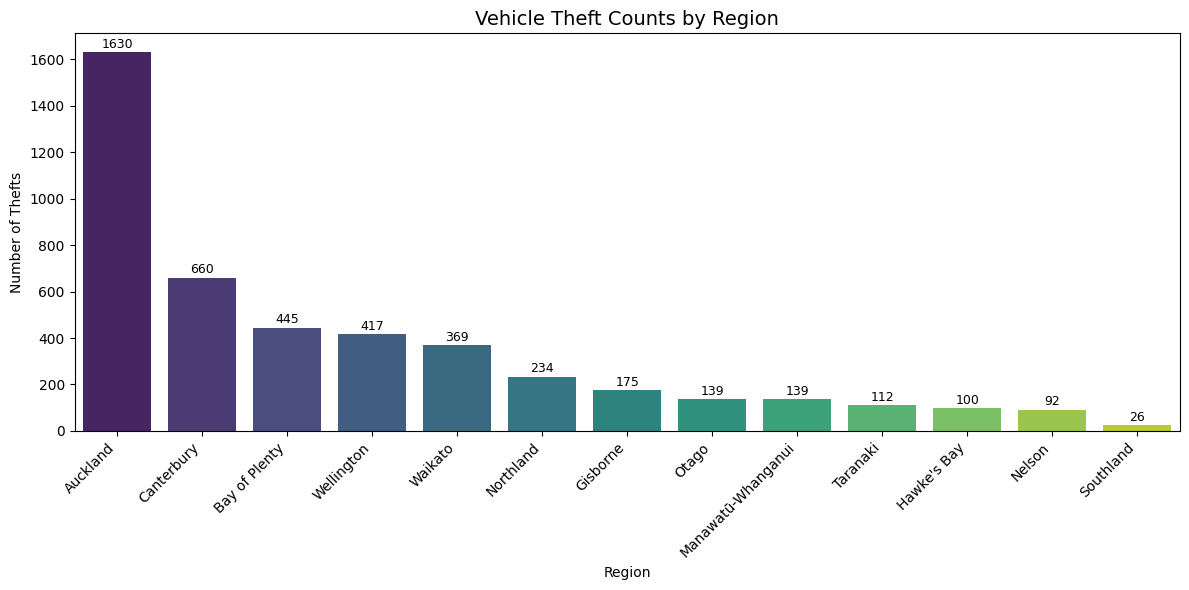

<Figure size 640x480 with 0 Axes>

In [9]:
# Theft counts per region
region_counts = df_merged.groupby(["region", "country"])["vehicle_id"].count().reset_index()
region_counts = region_counts.sort_values(by="vehicle_id", ascending=False)

plt.figure(figsize=(12, 6))

ax = sns.barplot( data=region_counts, x="region", y="vehicle_id", hue="region", palette="viridis", legend=False)

# Adding data labels on top of each bar
for i, value in enumerate(region_counts["vehicle_id"]):
    ax.text(i, value + 5, str(int(value)), ha='center', va='bottom', fontsize=9)

plt.title("Vehicle Theft Counts by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Number of Thefts")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('Vehicle Theft Counts by Region.png')


In [10]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4538 entries, 0 to 4537
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   vehicle_id    4538 non-null   int64         
 1   vehicle_type  4538 non-null   object        
 2   make_id       4538 non-null   int64         
 3   model_year    4538 non-null   int64         
 4   vehicle_desc  4538 non-null   object        
 5   color         4538 non-null   object        
 6   date_stolen   4538 non-null   datetime64[ns]
 7   location_id   4538 non-null   int64         
 8   year_stolen   4538 non-null   int32         
 9   month_stolen  4538 non-null   int32         
 10  month_name    4538 non-null   object        
 11  day_of_week   4538 non-null   object        
 12  make_name     4538 non-null   object        
 13  make_type     4538 non-null   object        
 14  region        4538 non-null   object        
 15  country       4538 non-null   object  

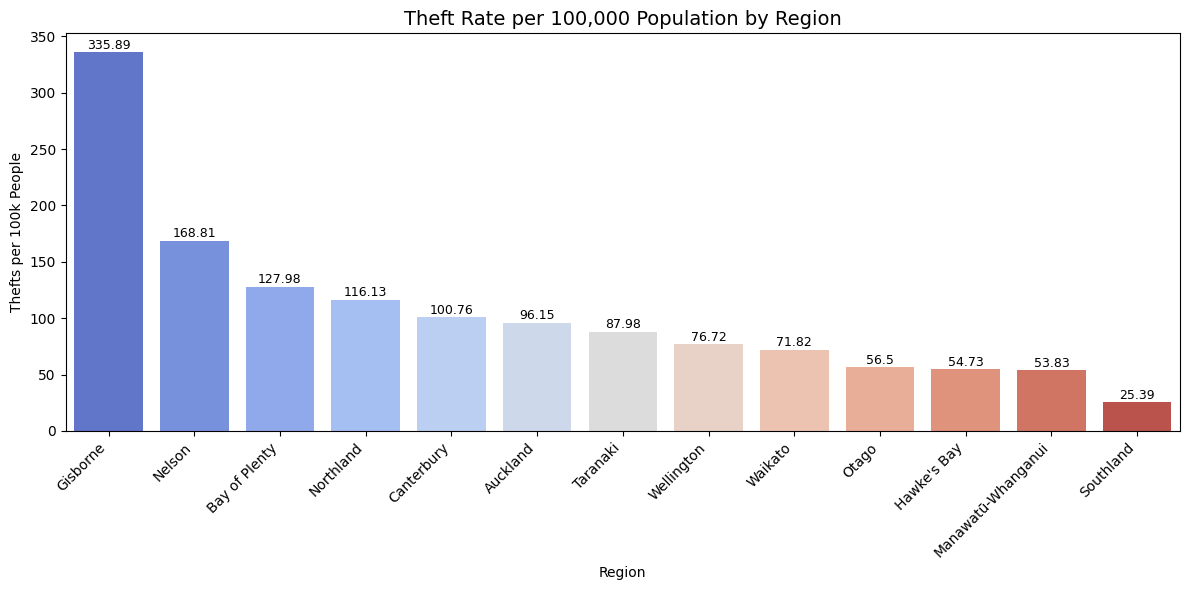

In [11]:


# population per region (avoiding duplication)
region_pop = df_merged[['region', 'population']].drop_duplicates()

# Aggregating population properly
region_pop = region_pop.groupby('region')['population'].sum().reset_index()

# Merging with theft counts
region_rate = region_counts.merge(region_pop, on='region')

# Calculation theft rate per 100k population
region_rate['theft_per_100k'] = (
    region_rate['vehicle_id'] / region_rate['population'] * 100000
).round(2)

# Sorting for better visualization
region_rate = region_rate.sort_values('theft_per_100k', ascending=False)

# Bargraph plot
plt.figure(figsize=(12, 6))

ax = sns.barplot(data=region_rate, x='region', y='theft_per_100k', hue='region', palette='coolwarm', legend=False)

# Adding data labels
for i, value in enumerate(region_rate['theft_per_100k']):
    ax.text(i, value + 0.5, str(value), ha='center', va='bottom', fontsize=9)

plt.title('Theft Rate per 100,000 Population by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Thefts per 100k People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

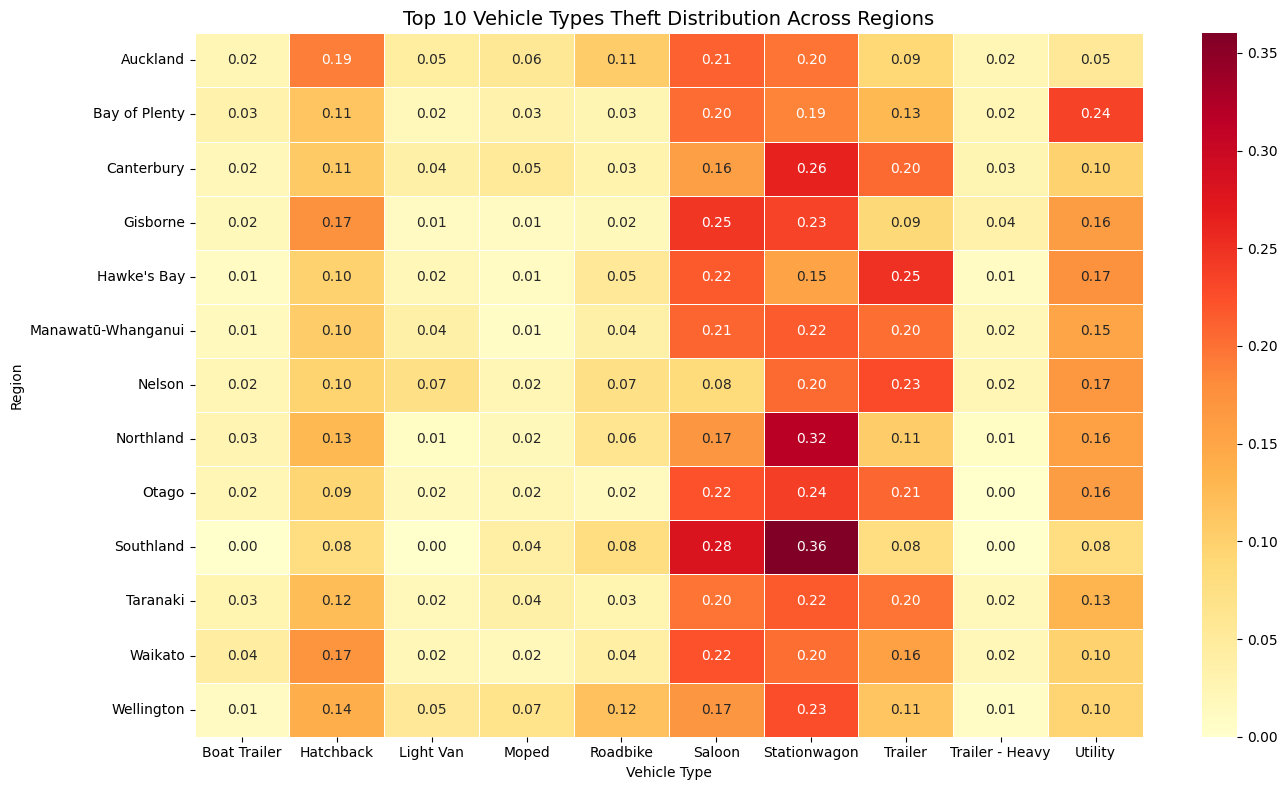

In [12]:
#  Top 10 most stolen vehicle types
top_vehicles = df_merged['vehicle_type'].value_counts().head(10).index

#  Filtering dataset for only those vehicle types
df_top = df_merged[df_merged['vehicle_type'].isin(top_vehicles)]

pivot_rt = df_top.pivot_table(
    index='region',
    columns='vehicle_type',
    values='vehicle_id',
    aggfunc='count',
    fill_value=0
)
# Normalize (row-wise percentage)
pivot_rt_norm = pivot_rt.div(pivot_rt.sum(axis=1), axis=0)

# heatmap
plt.figure(figsize=(14, 8))

sns.heatmap(pivot_rt_norm, cmap='YlOrRd', linewidths=0.5, annot=True, fmt=".2f")

plt.title('Top 10 Vehicle Types Theft Distribution Across Regions', fontsize=14)
plt.xlabel('Vehicle Type')
plt.ylabel('Region')
plt.tight_layout()
plt.show()



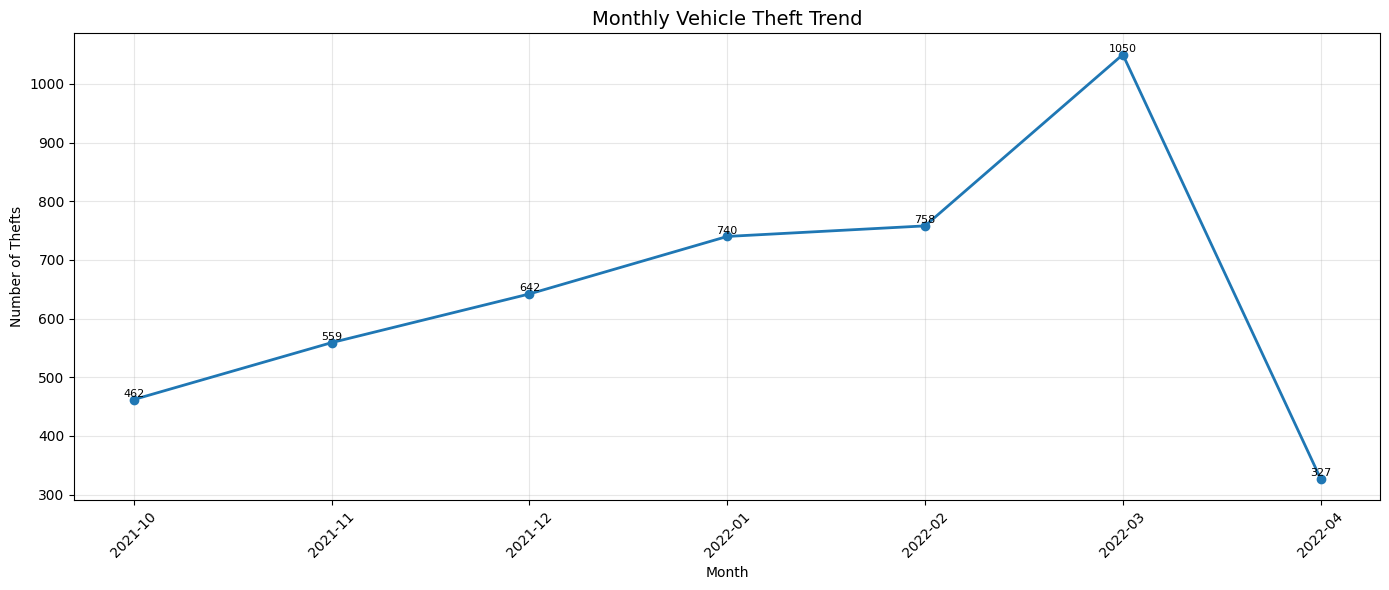

In [13]:
# Monthly theft trend
monthly = (
    df_merged.groupby(df_merged['date_stolen'].dt.to_period('M'))['vehicle_id']
    .count()
    .reset_index()
)

monthly.columns = ['month', 'theft_count']
monthly['month'] = monthly['month'].astype(str)
monthly = monthly.sort_values('month')
plt.figure(figsize=(14, 6))

plt.plot(
    monthly['month'],
    monthly['theft_count'],
    marker='o',
    linewidth=2
)
 
for i, value in enumerate(monthly['theft_count']):
    plt.text(
        monthly['month'].iloc[i],
        value + 5,
        str(value),
        ha='center',
        fontsize=8
    )

plt.title('Monthly Vehicle Theft Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Thefts')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

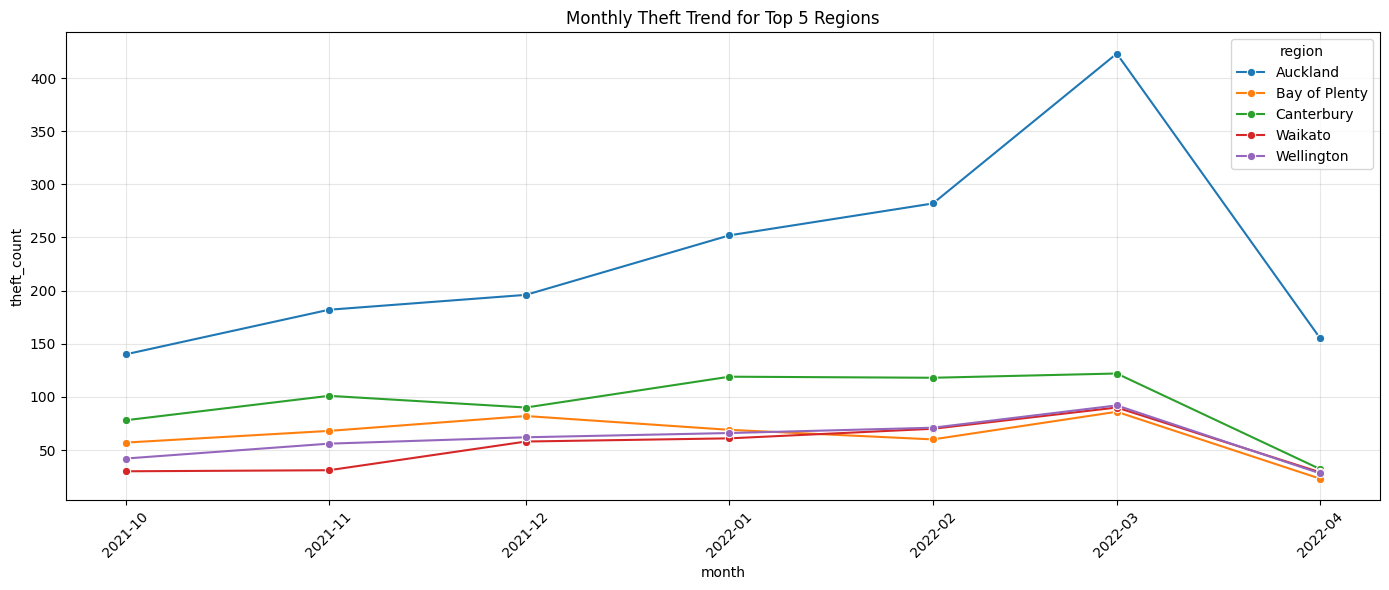

In [14]:
# Top 5 regions by theft count

top_regions = df_merged['region'].value_counts().head(5).index
df_top = df_merged[df_merged['region'].isin(top_regions)]
monthly_region = (
    df_top.groupby([
        df_top['date_stolen'].dt.to_period('M'),
        'region'
    ])['vehicle_id']
    .count()
    .reset_index()
)

monthly_region.columns = ['month', 'region', 'theft_count']
monthly_region['month'] = monthly_region['month'].dt.to_timestamp()

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_region,
    x='month',
    y='theft_count',
    hue='region',
    marker='o'
)

plt.title('Monthly Theft Trend for Top 5 Regions')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

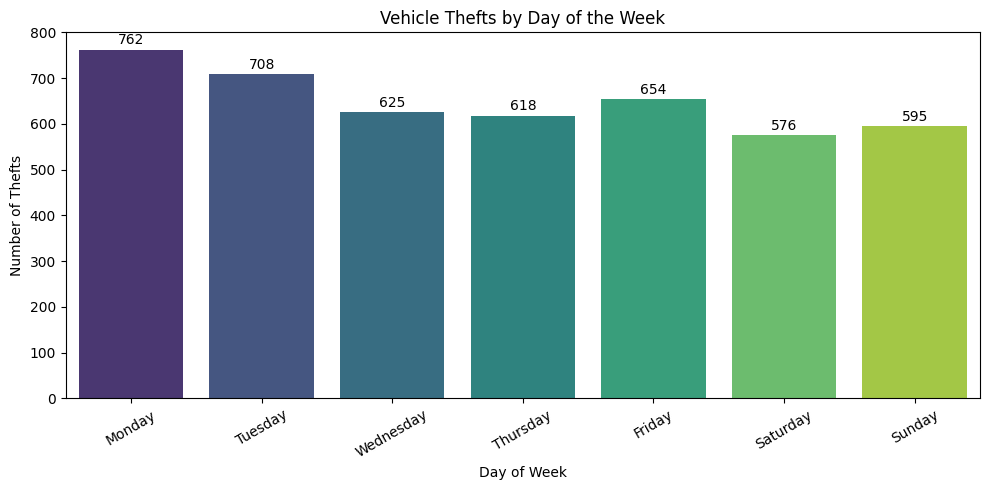

In [15]:
# Day-of-week pattern
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df_merged['day_of_week'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))

ax = sns.barplot(x=dow.index, y=dow.values, hue=dow.index, palette='viridis', legend=False)

# Adding data labels
for i, value in enumerate(dow.values):
    ax.text(i, value + 5, str(int(value)), ha='center', va='bottom')

plt.title('Vehicle Thefts by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Thefts')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

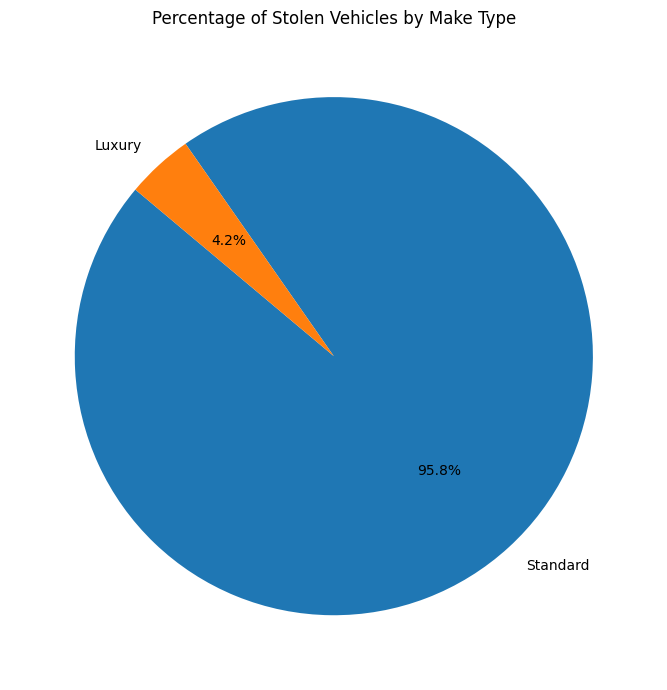

In [16]:
# Percentage Count of stolen vehicles by make_type (luxury vs. non-luxury vehicles)

make_counts = df_merged['make_type'].value_counts(normalize=True) * 100

# Plotting pie chart
plt.figure(figsize=(7,7))

plt.pie(make_counts, labels=make_counts.index, autopct='%1.1f%%', startangle=140)

plt.title('Percentage of Stolen Vehicles by Make Type')
plt.tight_layout()
plt.show()





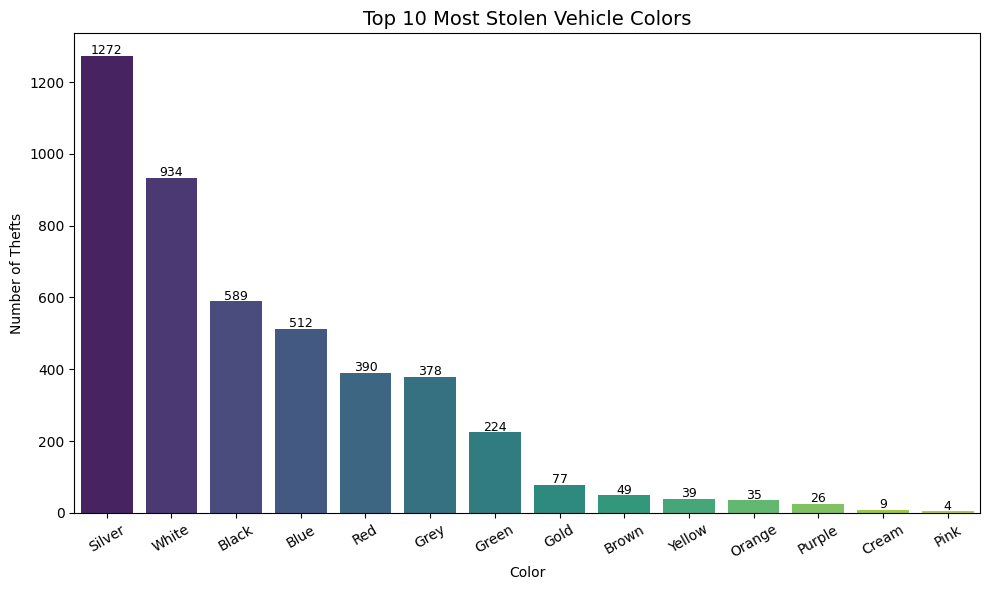

In [17]:
# Count of stolen vehicles by color
color_counts = df_merged['color'].value_counts()
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=color_counts.index,
    y=color_counts.values,
    hue=color_counts.index,
    palette='viridis',
    legend=False
)

for i, value in enumerate(color_counts.values):
    ax.text(i, value + 5, str(int(value)), ha='center', fontsize=9)

plt.title('Top 10 Most Stolen Vehicle Colors', fontsize=14)
plt.xlabel('Color')
plt.ylabel('Number of Thefts')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

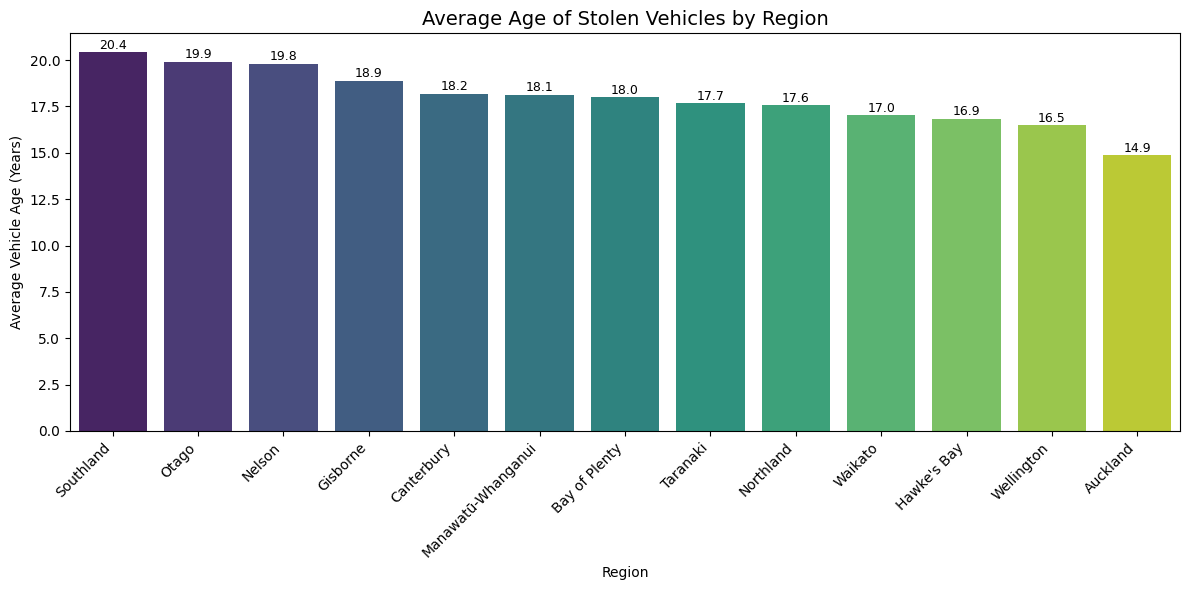

In [18]:
# Average age analysis of the stolen cars per region.

current_year = df_merged['year_stolen'].max()
df_merged['vehicle_age'] = current_year - df_merged['model_year']

avg_age_region = (
    df_merged.groupby('region')['vehicle_age']
    .mean()
    .reset_index()
    .sort_values(by='vehicle_age', ascending=False)
)

avg_age_region.head()
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=avg_age_region,
    x='region',
    y='vehicle_age',
    hue='region',
    palette='viridis',
    legend=False
)

for i, value in enumerate(avg_age_region['vehicle_age']):
    ax.text(i, value + 0.2, f"{value:.1f}", ha='center', fontsize=9)

plt.title('Average Age of Stolen Vehicles by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Average Vehicle Age (Years)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
#Reframing project to Risk Prediction Model

### Due to the absence of recovery-related variables, a proxy target variable (‘high_risk’) will be created based on regional theft frequency.
#Regions with higher theft frequency are considered high-risk.
#High theft region → High Risk (1)
#Low theft region → Low Risk (0)


In [20]:
# Counting number of thefts in each region
region_counts = df_merged['region'].value_counts()
region_counts.head()


region
Auckland         1630
Canterbury        660
Bay of Plenty     445
Wellington        417
Waikato           369
Name: count, dtype: int64

In [21]:
# Defining threshold using median (balance split)
threshold = region_counts.median()
print("Threshold (median theft count):", threshold)

Threshold (median theft count): 175.0


In [22]:
# Creating the high_risk target variable (column)
# Regions with theft count > median → High Risk (1), else Low Risk (0)

df_merged['high_risk'] = df_merged['region'].map(region_counts) > threshold

In [23]:
# Converting boolean to integer (True → 1, False → 0)
df_merged['high_risk'] = df_merged['high_risk'].astype(int)

In [24]:
# Checking how many high risk vs low risk samples
df_merged['high_risk'].value_counts()

high_risk
1    3755
0     783
Name: count, dtype: int64

In [25]:
# Viewing few rows to confirm column is created correctly
df_merged[['region', 'high_risk']].head()

,region,high_risk
0,Auckland,1
1,Gisborne,0
2,Auckland,1
3,Hawke's Bay,0
4,Auckland,1


In [26]:
# Here, Ratio ≈ 83% vs 17% ; this means data seems as imbalance.
# Continuing with this same data; Model may just predict “high risk” always which is poor learning for model.
# so, even though data is imbalance we first build the baseline model (without handling imbalance data).
# later, we try technique called Class Weighting to improve model handling imbalance data & do comparison.


In [27]:
#Feature Selection
# we keep only useful features what goes into the model (X).
# we drop 'region' from features because as our target (high_risk) is based on region; so if we include region as a feature 
# model will easily learn shortcut and it becomes too obvious / less meaningful. 
#(Avoiding leakage and forcing model to learn patterns from other features.)

In [28]:
# Selecting useful features for model

features = [
    'vehicle_type',
    'color',
    'make_type',
    'model_year',
    'vehicle_age',
    'month_stolen',
    'day_of_week'
]

X = df_merged[features]
y = df_merged['high_risk']

In [29]:
print("Shape of Features :", X.shape)
print("Shape of Target :", y.shape)
X.head()

Shape of Features : (4538, 7)
Shape of Target : (4538,)


,vehicle_type,color,make_type,model_year,vehicle_age,month_stolen,day_of_week
0,Trailer,Silver,Standard,2021,1,11,Friday
1,Boat Trailer,Silver,Standard,2021,1,12,Monday
2,Boat Trailer,Silver,Standard,2021,1,2,Sunday
3,Trailer,Silver,Standard,2021,1,11,Saturday
4,Trailer,Silver,Standard,2018,4,1,Monday


In [30]:
# Encoding 

# ML models cannot understand text (categorical data)
# converting : vehicle_type, color, make_type, day_of_week into numerical format.

In [31]:
# Converting categorical variables into numeric using One-Hot Encoding
X_encoded = pd.get_dummies(
    X,
    columns=['vehicle_type', 'color', 'make_type', 'day_of_week'],
    drop_first=True   # avoids dummy variable trap
)
print("Encoded feature shape:", X_encoded.shape)
X_encoded.head()

Encoded feature shape: (4538, 48)


,model_year,vehicle_age,month_stolen,vehicle_type_Articulated Truck,vehicle_type_Boat Trailer,vehicle_type_Cab and Chassis Only,vehicle_type_Caravan,vehicle_type_Convertible,vehicle_type_Flat Deck Truck,vehicle_type_Hatchback,...,color_Silver,color_White,color_Yellow,make_type_Standard,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,2021,1,11,False,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
1,2021,1,12,False,True,False,False,False,False,False,...,True,False,False,True,True,False,False,False,False,False
2,2021,1,2,False,True,False,False,False,False,False,...,True,False,False,True,False,False,True,False,False,False
3,2021,1,11,False,False,False,False,False,False,False,...,True,False,False,True,False,True,False,False,False,False
4,2018,4,1,False,False,False,False,False,False,False,...,True,False,False,True,True,False,False,False,False,False


In [32]:
#Train-Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3630, 48)
Test size: (908, 48)


### Logistic Regression

In [33]:
# Model training
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [34]:
# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.816079295154185

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       167
           1       0.82      1.00      0.90       741

    accuracy                           0.82       908
   macro avg       0.41      0.50      0.45       908
weighted avg       0.67      0.82      0.73       908



C:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [35]:
# Although the baseline model achieved an accuracy of 82%, it failed to correctly identify the minority class (low risk instances), 
# indicating a bias toward the majority class due to class imbalance.
## This confirms that : Imbalanced data → biased model

## Handling Imbalance Data using Class Weighting

In [36]:
# Training model with class_weight

# Logistic Regression with class balancing
model_balanced = LogisticRegression(max_iter=5000, class_weight='balanced')

model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)


In [37]:
## Model Evaluation 
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy (Balanced):", accuracy_score(y_test, y_pred_balanced))
print("\nClassification Report (Balanced):\n")
print(classification_report(y_test, y_pred_balanced))



Accuracy (Balanced): 0.566079295154185

Classification Report (Balanced):

              precision    recall  f1-score   support

           0       0.24      0.62      0.35       167
           1       0.87      0.55      0.68       741

    accuracy                           0.57       908
   macro avg       0.55      0.59      0.51       908
weighted avg       0.75      0.57      0.61       908



In [38]:
#Comparison between Baseline model and Balanced model
#Improved recall for the minority class (low-risk regions), increasing from 0.00 to 0.62.
#Although overall accuracy decreased, the model became more balanced and reliable for classification tasks.

# Feature Importance

In [39]:
# Getting feature importance from logistic regression

feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model_balanced.coef_[0]
})

# Sort by importance
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

feature_importance.head(10)

,Feature,Coefficient
7,vehicle_type_Convertible,1.335587
30,color_Cream,0.901752
10,vehicle_type_Heavy Van,0.896529
11,vehicle_type_Light Bus,0.736699
15,vehicle_type_Moped,0.648572
22,vehicle_type_Tractor,0.566434
35,color_Pink,0.534752
17,vehicle_type_Roadbike,0.455445
46,day_of_week_Tuesday,0.345308
14,vehicle_type_Mobile Machine,0.301107


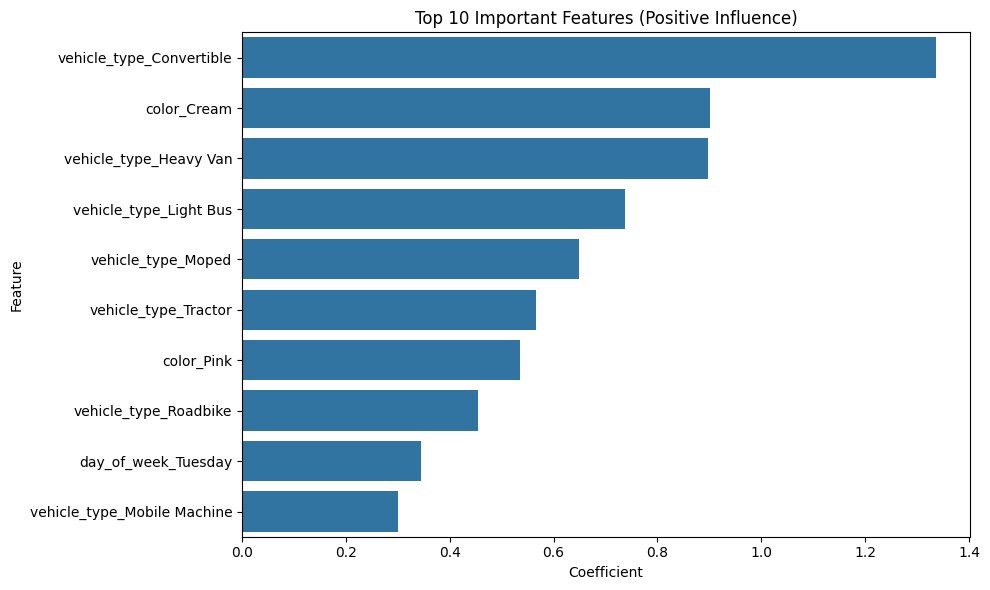

In [40]:
##Visualizing (Top features)

plt.figure(figsize=(10,6))

top_features = feature_importance.head(10)

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top_features
)

plt.title('Top 10 Important Features (Positive Influence)')
plt.tight_layout()
plt.show()

In [41]:
# Getting feature importance from logistic regression

feature_importance = pd.DataFrame({
    'Features': X_encoded.columns,
    'Coefficient': model_balanced.coef_[0]
})

# Sort by importance
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

feature_importance.tail(10)

,Features,Coefficient
37,color_Red,-0.494114
20,vehicle_type_Sports Car,-0.538018
27,vehicle_type_Utility,-0.547755
8,vehicle_type_Flat Deck Truck,-0.570182
26,vehicle_type_Unknown,-0.574607
41,make_type_Standard,-0.618462
36,color_Purple,-0.734901
24,vehicle_type_Trailer,-0.742719
31,color_Gold,-0.822557
13,vehicle_type_Mobile Home - Light,-1.088556


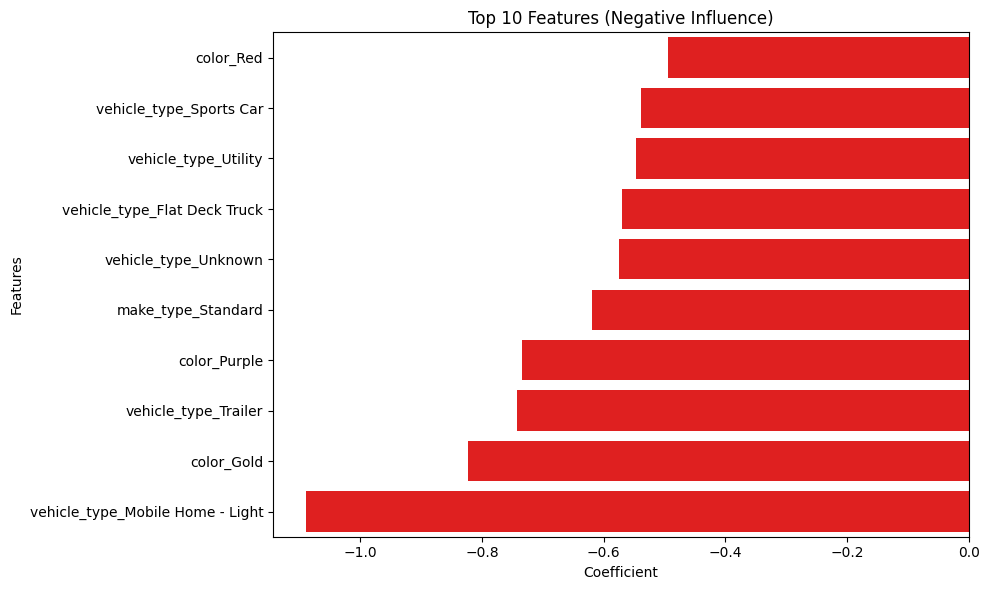

In [42]:
## Negative impact features

bottom_features = feature_importance.tail(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x='Coefficient',
    y='Features',
    data=bottom_features,
    color='red'
)

plt.title('Top 10 Features (Negative Influence)')
plt.tight_layout()
plt.show()

In [43]:
##Intrepretation :
#Positive coefficient -> increases probability of high risk
#Negative coefficient -> decreases probability

In [44]:
## But while looking at our real datasets separately  we noticed that the features with few samples appeard as top positive influence feature.
## This is known behavior in Logistic Regression (Coefficient shows strength of association, not frequency).
## But saying that , we need to be aware of Rare category bias as well.
## Feature importance analysis revealed potential bias due to rare categories.
## Therefore, low frequency categories can be grouped to improve model robustness. 

In [45]:
# Checking frequency of categorical features

print("Vehicle Type:\n", df_merged['vehicle_type'].value_counts())
print("\n------------------\n")

print("Color:\n", df_merged['color'].value_counts())
print("\n------------------\n")

print("Make Type:\n", df_merged['make_type'].value_counts())

Vehicle Type:
 vehicle_type
Stationwagon               945
Saloon                     851
Hatchback                  644
Trailer                    582
Utility                    466
Roadbike                   297
Moped                      187
Light Van                  154
Boat Trailer               105
Trailer - Heavy             90
Caravan                     44
Other Truck                 42
Sports Car                  40
Flat Deck Truck             17
Mobile Home - Light         15
Convertible                 12
Unknown                     11
Cab and Chassis Only         8
Heavy Van                    7
Light Bus                    6
All Terrain Vehicle          5
Tractor                      4
Trail Bike                   2
Mobile Machine               2
Special Purpose Vehicle      1
Articulated Truck            1
Name: count, dtype: int64

------------------

Color:
 color
Silver    1272
White      934
Black      589
Blue       512
Red        390
Grey       378
Green      224


#### Rare Category Handling

In [46]:
## Defining Any category with less than 50 samples = rare

threshold = 50

In [47]:
# Clean vehicle_type

## lets Identify rare vehicle types
vehicle_counts = df_merged['vehicle_type'].value_counts()
rare_vehicle_types = vehicle_counts[vehicle_counts < threshold].index

## Replacing rare values with 'Other'
df_merged['vehicle_type_clean'] = df_merged['vehicle_type'].replace(rare_vehicle_types, 'Other')

In [48]:
# Clean color

## lets Identify rare colors
color_counts = df_merged['color'].value_counts()
rare_colors = color_counts[color_counts < threshold].index

## Replacing rare colors with 'Other'
df_merged['color_clean'] = df_merged['color'].replace(rare_colors, 'Other')

In [49]:
# make_type
## We keep make_type as it is, as it has it has few categories (e.g., Standard, Luxury).

In [50]:
# New Updated Features
features = [
    'vehicle_type_clean',
    'color_clean',
    'make_type',
    'model_year',
    'vehicle_age',
    'month_stolen',
    'day_of_week'
]

X = df_merged[features]
y = df_merged['high_risk']

In [51]:
#Repeating Encoding

X_encoded = pd.get_dummies(
    X,
    columns=['vehicle_type_clean', 'color_clean', 'make_type', 'day_of_week'],
    drop_first=True
)

In [52]:
# Train-Test Split Again

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
# Training Balanced Model again

from sklearn.linear_model import LogisticRegression

model_clean = LogisticRegression(max_iter=5000, class_weight='balanced')

model_clean.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [54]:
# Model evaluation again

from sklearn.metrics import classification_report, accuracy_score

y_pred_clean = model_clean.predict(X_test)

print("Accuracy (Cleaned):", accuracy_score(y_test, y_pred_clean))
print("\nClassification Report (Cleaned):\n")
print(classification_report(y_test, y_pred_clean))

Accuracy (Cleaned): 0.5561674008810573

Classification Report (Cleaned):

              precision    recall  f1-score   support

           0       0.24      0.63      0.34       167
           1       0.87      0.54      0.66       741

    accuracy                           0.56       908
   macro avg       0.55      0.59      0.50       908
weighted avg       0.75      0.56      0.61       908



In [55]:
## Feature Importance Again
feature_importance_clean = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model_clean.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

feature_importance_clean.head(10)

,Feature,Coefficient
5,vehicle_type_clean_Moped,0.673558
7,vehicle_type_clean_Roadbike,0.475728
26,day_of_week_Tuesday,0.339527
4,vehicle_type_clean_Light Van,0.185611
3,vehicle_type_clean_Hatchback,0.184634
24,day_of_week_Sunday,0.102436
27,day_of_week_Wednesday,0.028461
25,day_of_week_Thursday,0.025179
22,day_of_week_Monday,0.007622
0,model_year,0.000659


In [56]:
# Before we had : Rare categories like Convertible dominated (wrong signal)
# We checked frequencies -> handled rare categories ->  rebuilt model -> rechecked importance
# so Now we have
   #Realistic categories appear (Moped, Roadbike)
   #No extreme weird coefficients
   #Model is more stable and believable


## Random Forest

In [57]:
# Model training

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [58]:
## Model Evaluation 

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf))

Accuracy (Random Forest): 0.7841409691629956

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.16      0.04      0.07       167
           1       0.82      0.95      0.88       741

    accuracy                           0.78       908
   macro avg       0.49      0.50      0.47       908
weighted avg       0.70      0.78      0.73       908



In [59]:
# Random Forest is again: Ignoring the minority class (0)
  ##Same problem we saw earlier in baseline Logistic Regression.
## We now try balance this for Random forest as well; as we did for Logistic Regression.



### Handling imbalance in Random Forest using Class Weighting

In [60]:
rf_model_balanced = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

rf_model_balanced.fit(X_train, y_train)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

In [61]:
## Evaluation
print("Accuracy (RF Balanced):", accuracy_score(y_test, y_pred_rf_balanced))
print("\nClassification Report (RF Balanced):\n")
print(classification_report(y_test, y_pred_rf_balanced))

Accuracy (RF Balanced): 0.7874449339207048

Classification Report (RF Balanced):

              precision    recall  f1-score   support

           0       0.19      0.05      0.08       167
           1       0.82      0.95      0.88       741

    accuracy                           0.79       908
   macro avg       0.50      0.50      0.48       908
weighted avg       0.70      0.79      0.73       908



In [62]:
## Logistic Regression responded well to class imbalance handling,
## while Random Forest is less sensitive to class weights compared to Logistic Regression.

### XGBoost Model

In [63]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
## Training Model

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

C:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:11:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [65]:
## Evaluation

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy (XGBoost):", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report (XGBoost):\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy (XGBoost): 0.7830396475770925

Classification Report (XGBoost):

              precision    recall  f1-score   support

           0       0.20      0.06      0.09       167
           1       0.82      0.95      0.88       741

    accuracy                           0.78       908
   macro avg       0.51      0.50      0.48       908
weighted avg       0.70      0.78      0.73       908



In [66]:
## indicating strong bias toward the majority class as similar to other baseline model.
##  we give a try with balancing data again for xgboost using scale_pos_weight parameter.

### Handling Imbalance in XGBoost using (scale_pos_weight)

In [67]:
# Calculating ratio (negative / positive)

ratio = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale Pos Weight:", ratio)

Scale Pos Weight: 0.20437956204379562


In [68]:
## Training Balance XGBoost

xgb_model_balanced = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=ratio
)

xgb_model_balanced.fit(X_train, y_train)

y_pred_xgb_bal = xgb_model_balanced.predict(X_test)

C:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:11:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [69]:
## Evaluation

print("Accuracy (XGBoost Balanced):", accuracy_score(y_test, y_pred_xgb_bal))
print("\nClassification Report (XGBoost Balanced):\n")
print(classification_report(y_test, y_pred_xgb_bal))

Accuracy (XGBoost Balanced): 0.6332599118942731

Classification Report (XGBoost Balanced):

              precision    recall  f1-score   support

           0       0.22      0.38      0.28       167
           1       0.83      0.69      0.75       741

    accuracy                           0.63       908
   macro avg       0.52      0.54      0.52       908
weighted avg       0.72      0.63      0.67       908



In [70]:
## XGBoost model showed a noticeable improvement in detecting the minority class, with recall increasing from 0.06 to 0.38.
## However, overall  accuracy get reduced and a slight decline in majority class performance.


## Model improvement and Validation steps

In [71]:
## To address class imbalance, accuracy alone is not used as the evaluation metric.
## Instead, ROC-AUC scores and confusion matrices can be used to assess each model's ability to correctly identify both high-risk and low-risk instances.

In [72]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

# We get predicted probabilities for all three balanced models
  ## Getting probability scores (not just 0/1 predictions) for ROC curve
  ## We need probability of class 1 (high_risk) — that's the [:, 1] part

prob_lr   = model_clean.predict_proba(X_test)[:, 1]         # Logistic Regression (balanced + rare fixed)
prob_rf   = rf_model_balanced.predict_proba(X_test)[:, 1]   # Random Forest balanced
prob_xgb  = xgb_model_balanced.predict_proba(X_test)[:, 1]  # XGBoost balanced


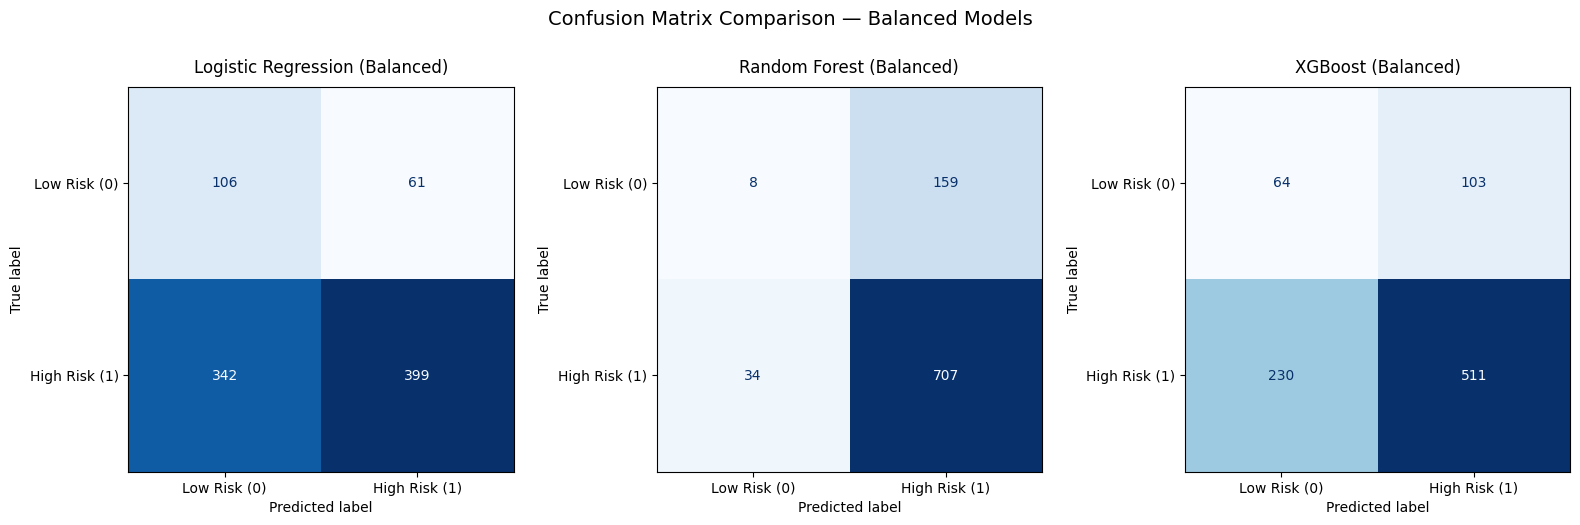

In [73]:
## Creating Confusion matrices for all three models 

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_info = [
    (y_pred_clean,       "Logistic Regression (Balanced)"),
    (y_pred_rf_balanced, "Random Forest (Balanced)"),
    (y_pred_xgb_bal,     "XGBoost (Balanced)")
]

for ax, (preds, title) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low Risk (0)", "High Risk (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=12, pad=10)
plt.suptitle("Confusion Matrix Comparison — Balanced Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

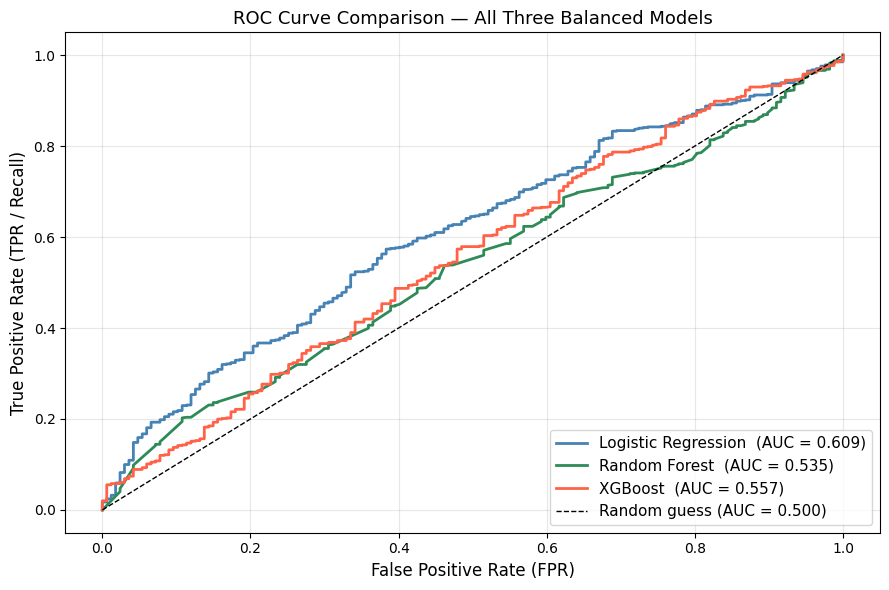

In [74]:
## ROC Curves for all three models on one plot
plt.figure(figsize=(9, 6))

models_roc = [
    (prob_lr,  y_pred_clean,       "Logistic Regression"),
    (prob_rf,  y_pred_rf_balanced, "Random Forest"),
    (prob_xgb, y_pred_xgb_bal,     "XGBoost")
]

colors = ["steelblue", "seagreen", "tomato"]

for (probs, preds, name), color in zip(models_roc, colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})", color=color, linewidth=2)

# Random classifier baseline (a model that just guesses)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random guess (AUC = 0.500)")

plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR / Recall)", fontsize=12)
plt.title("ROC Curve Comparison — All Three Balanced Models", fontsize=13)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
## Checking AUC scores summary for better decision

print("=" * 45)
print("       ROC-AUC Score Summary (Balanced)")
print("=" * 45)

auc_lr  = roc_auc_score(y_test, prob_lr)
auc_rf  = roc_auc_score(y_test, prob_rf)
auc_xgb = roc_auc_score(y_test, prob_xgb)

print(f"  Logistic Regression : {auc_lr:.4f}")
print(f"  Random Forest       : {auc_rf:.4f}")
print(f"  XGBoost             : {auc_xgb:.4f}")
print("=" * 45)

best_model = max(
    [("Logistic Regression", auc_lr),
     ("Random Forest",       auc_rf),
     ("XGBoost",             auc_xgb)],
    key=lambda x: x[1]
)
print(f"\n  Best model: {best_model[0]}  (AUC = {best_model[1]:.4f})")

       ROC-AUC Score Summary (Balanced)
  Logistic Regression : 0.6094
  Random Forest       : 0.5355
  XGBoost             : 0.5569

  Best model: Logistic Regression  (AUC = 0.6094)


In [76]:
## We used ROC-AUC as our primary evaluation metric because accuracy alone was misleading for imbalanced data.
## Logistic Regression achieved the highest AUC of 0.61, meaning it correctly discriminates between high-risk and low-risk theft cases 61% of the time.
## The moderate AUC scores across all models are expected given that our target variable is a proxy label derived from regional theft frequency 
## ..rather than a true ground-truth outcome variable.

## Creating Stratified Cross-Validation

In [77]:
## We validate our best model — balanced Logistic Regression — using Stratified 5-fold Cross-Validation to check model performance across multiple data splits,

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Defining the model 
model_cv = LogisticRegression(max_iter=5000, class_weight='balanced')

# Stratified 5-fold ; keeps the 83/17 class ratio in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate for Accuracy
cv_accuracy = cross_val_score(model_cv, X_encoded, y,
                               cv=skf, scoring='accuracy')

# Cross-validate for ROC-AUC
cv_auc = cross_val_score(model_cv, X_encoded, y,
                          cv=skf, scoring='roc_auc')

# Results
print("=" * 50)
print("  Stratified 5-Fold Cross-Validation Results")
print("  Model: Logistic Regression (Balanced)")
print("=" * 50)
print(f"\n  Accuracy  per fold : {np.round(cv_accuracy, 4)}")
print(f"  Mean Accuracy      : {cv_accuracy.mean():.4f}")
print(f"  Std Deviation      : {cv_accuracy.std():.4f}")
print()
print(f"  AUC per fold       : {np.round(cv_auc, 4)}")
print(f"  Mean AUC           : {cv_auc.mean():.4f}")
print(f"  Std Deviation      : {cv_auc.std():.4f}")
print("=" * 50)

  Stratified 5-Fold Cross-Validation Results
  Model: Logistic Regression (Balanced)

  Accuracy  per fold : [0.5749 0.5562 0.5782 0.5799 0.5645]
  Mean Accuracy      : 0.5707
  Std Deviation      : 0.0090

  AUC per fold       : [0.6014 0.5974 0.6207 0.6184 0.6005]
  Mean AUC           : 0.6077
  Std Deviation      : 0.0098


In [78]:
## We used stratified cross-validation to make sure the model performance was consistent and not dependent on one train-test split.
## The low standard deviation showed that the model behaved similarly across all folds indicating stable generalization capability.


## Clear Visualization of all Classification Model Performance we used 

In [79]:

# All predictions & probabilities already exist above

# Baseline predictions
pred_lr_base  = y_pred          # Logistic Regression baseline
pred_rf_base  = y_pred_rf       # Random Forest baseline
pred_xgb_base = y_pred_xgb     # XGBoost baseline

# Balanced predictions
pred_lr_bal   = y_pred_clean        # LR balanced + rare fixed
pred_rf_bal   = y_pred_rf_balanced  # RF balanced
pred_xgb_bal  = y_pred_xgb_bal     # XGBoost balanced

# Probabilities (for AUC)
prob_lr_bal   = model_clean.predict_proba(X_test)[:, 1]
prob_rf_bal   = rf_model_balanced.predict_proba(X_test)[:, 1]
prob_xgb_bal  = xgb_model_balanced.predict_proba(X_test)[:, 1]

## SUMMARY TABLE 

from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, y_prob=None):
    acc      = accuracy_score(y_true, y_pred)
    prec_0   = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    rec_0    = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1_0     = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    prec_1   = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec_1    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_1     = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    auc      = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    return acc, prec_0, rec_0, f1_0, prec_1, rec_1, f1_1, auc

rows = [
    ("Logistic Regression", "Baseline",  pred_lr_base,  None),
    ("Logistic Regression", "Balanced",  pred_lr_bal,   prob_lr_bal),
    ("Random Forest",       "Baseline",  pred_rf_base,  None),
    ("Random Forest",       "Balanced",  pred_rf_bal,   prob_rf_bal),
    ("XGBoost",             "Baseline",  pred_xgb_base, None),
    ("XGBoost",             "Balanced",  pred_xgb_bal,  prob_xgb_bal),
]

cols = ["Model", "Version", "Accuracy",
        "Prec(0)", "Rec(0)", "F1(0)",
        "Prec(1)", "Rec(1)", "F1(1)", "ROC-AUC"]

data = []
for model_name, version, preds, probs in rows:
    acc, p0, r0, f0, p1, r1, f1, auc = get_metrics(y_test, preds, probs)
    auc_str = f"{auc:.4f}" if auc else "—"
    data.append([model_name, version,
                 f"{acc:.4f}", f"{p0:.4f}", f"{r0:.4f}", f"{f0:.4f}",
                 f"{p1:.4f}", f"{r1:.4f}", f"{f1:.4f}", auc_str])

summary_df = pd.DataFrame(data, columns=cols)

print("\n" + "="*105)
print("   VEHICLE THEFT RISK PREDICTION — CLASSIFICATION MODEL COMPARISON SUMMARY")
print("="*105)
print(summary_df.to_string(index=False))
print("="*105)
print("\n  Class 0 = Low Risk  |  Class 1 = High Risk")
print("  Rec(0): minority class recall — key metric for imbalance")
print("  ROC-AUC: only for balanced models (meaningful with class weights)")


   VEHICLE THEFT RISK PREDICTION — CLASSIFICATION MODEL COMPARISON SUMMARY
              Model  Version Accuracy Prec(0) Rec(0)  F1(0) Prec(1) Rec(1)  F1(1) ROC-AUC
Logistic Regression Baseline   0.8161  0.0000 0.0000 0.0000  0.8161 1.0000 0.8987       —
Logistic Regression Balanced   0.5562  0.2366 0.6347 0.3447  0.8674 0.5385 0.6644  0.6094
      Random Forest Baseline   0.7841  0.1628 0.0419 0.0667  0.8150 0.9514 0.8780       —
      Random Forest Balanced   0.7874  0.1905 0.0479 0.0766  0.8164 0.9541 0.8799  0.5355
            XGBoost Baseline   0.7830  0.2000 0.0599 0.0922  0.8170 0.9460 0.8768       —
            XGBoost Balanced   0.6333  0.2177 0.3832 0.2777  0.8322 0.6896 0.7542  0.5569

  Class 0 = Low Risk  |  Class 1 = High Risk
  Rec(0): minority class recall — key metric for imbalance
  ROC-AUC: only for balanced models (meaningful with class weights)


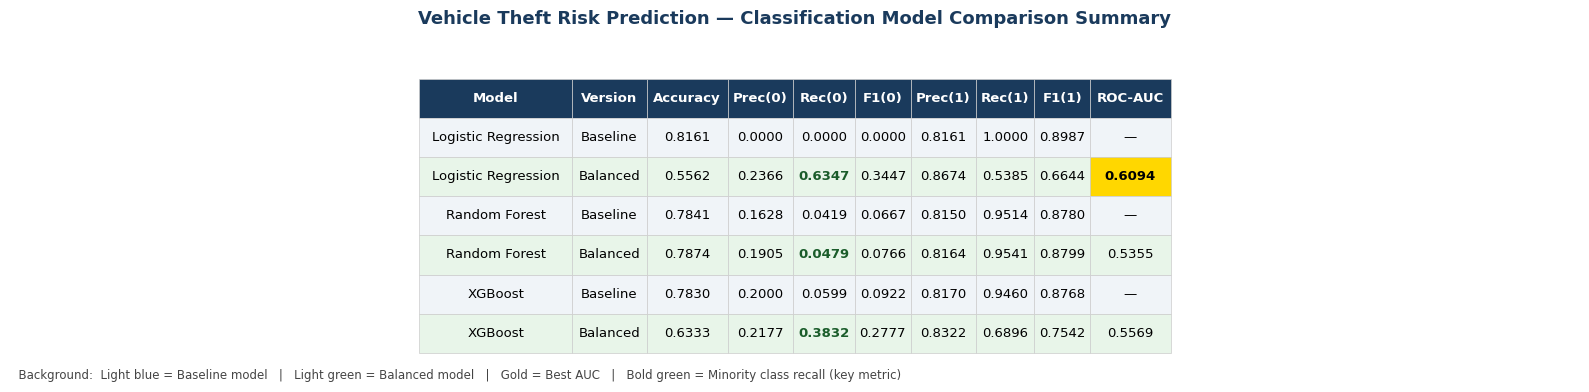

In [80]:
## VISUAL SUMMARY TABLE 

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

table_data = [cols] + data

table = ax.table(
    cellText=data,
    colLabels=cols,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.2)

# Styling 
header_color  = "#1a3a5c"
baseline_color = "#f0f4f8"
balanced_color = "#e8f5e9"
highlight_color = "#fff3cd"

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#cccccc')
    cell.set_linewidth(0.5)

    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color='white', fontweight='bold')

    elif row in [1, 3, 5]:   # Baseline rows
        cell.set_facecolor(baseline_color)

    elif row in [2, 4, 6]:   # Balanced rows
        cell.set_facecolor(balanced_color)

    # Highlight best AUC cell (LR balanced = row 2, col 9)
    if row == 2 and col == 9:
        cell.set_facecolor("#ffd700")
        cell.set_text_props(fontweight='bold')

    # Highlight Rec(0) column for balanced rows
    if col == 4 and row in [2, 4, 6]:
        cell.set_text_props(fontweight='bold', color='#1a5c2a')

# Column widths
col_widths = [0.16, 0.10, 0.09, 0.09, 0.09, 0.08, 0.09, 0.09, 0.08, 0.09]
for col_idx, width in enumerate(col_widths):
    table.auto_set_column_width(col_idx)

plt.title("Vehicle Theft Risk Prediction — Classification Model Comparison Summary",
          fontsize=13, fontweight='bold', pad=20, color='#1a3a5c')

# Legend
fig.text(0.01, 0.04,
         "  Background:  Light blue = Baseline model   |   Light green = Balanced model   |"
         "   Gold = Best AUC   |   Bold green = Minority class recall (key metric)",
         fontsize=8.5, color='#444444')

plt.tight_layout()
plt.savefig('classification_model_comparison_table.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()

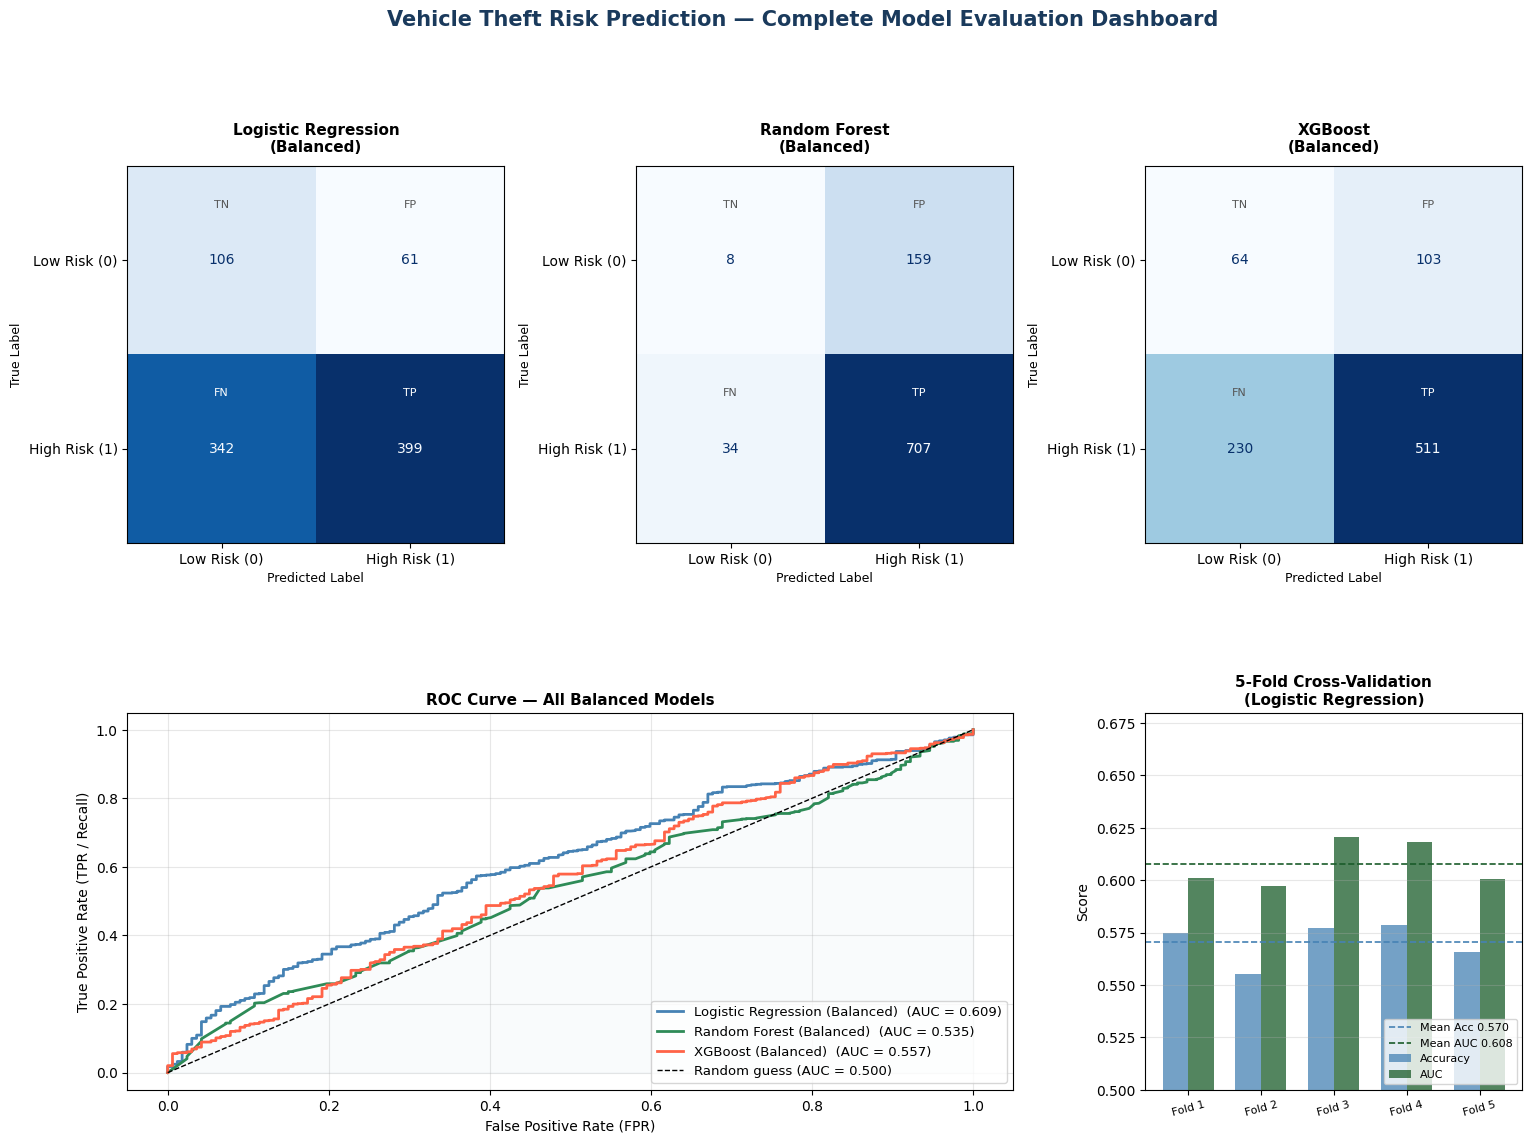

In [81]:
## Final visual dashboard (confusion matrices + ROC together)

import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Vehicle Theft Risk Prediction — Complete Model Evaluation Dashboard",
             fontsize=15, fontweight='bold', color='#1a3a5c', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Row 1: Confusion matrices 
cm_models = [
    (pred_lr_bal,  "Logistic Regression\n(Balanced)"),
    (pred_rf_bal,  "Random Forest\n(Balanced)"),
    (pred_xgb_bal, "XGBoost\n(Balanced)")
]

for i, (preds, title) in enumerate(cm_models):
    ax = fig.add_subplot(gs[0, i])
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Low Risk (0)", "High Risk (1)"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel("Predicted Label", fontsize=9)
    ax.set_ylabel("True Label", fontsize=9)

    # Annotate TN, FP, FN, TP
    labels = [["TN", "FP"], ["FN", "TP"]]
    for r in range(2):
        for c in range(2):
            ax.text(c, r - 0.28, labels[r][c],
                    ha='center', fontsize=8,
                    color='white' if cm[r, c] > cm.max()/2 else '#555555')

#  Row 2: ROC Curve (span 2 cols) + Cross-val bar (1 col) 
ax_roc = fig.add_subplot(gs[1, :2])

roc_models = [
    (prob_lr_bal,  "Logistic Regression (Balanced)", "steelblue"),
    (prob_rf_bal,  "Random Forest (Balanced)",       "seagreen"),
    (prob_xgb_bal, "XGBoost (Balanced)",             "tomato")
]

for probs, name, color in roc_models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax_roc.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})",
                color=color, linewidth=2)

ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random guess (AUC = 0.500)")
ax_roc.fill_between(fpr, tpr, alpha=0.03, color='steelblue')
ax_roc.set_xlabel("False Positive Rate (FPR)", fontsize=10)
ax_roc.set_ylabel("True Positive Rate (TPR / Recall)", fontsize=10)
ax_roc.set_title("ROC Curve — All Balanced Models", fontsize=11,
                  fontweight='bold')
ax_roc.legend(loc="lower right", fontsize=9.5)
ax_roc.grid(alpha=0.3)

# Cross-validation bar (right column) 
ax_cv = fig.add_subplot(gs[1, 2])

folds      = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
cv_acc_vals = [0.5749, 0.5551, 0.5771, 0.5788, 0.5656]
cv_auc_vals = [0.6011, 0.5973, 0.6205, 0.6184, 0.6005]

x = np.arange(len(folds))
width = 0.35

bars1 = ax_cv.bar(x - width/2, cv_acc_vals, width,
                   label='Accuracy', color='steelblue', alpha=0.75)
bars2 = ax_cv.bar(x + width/2, cv_auc_vals, width,
                   label='AUC',      color='#1a5c2a',  alpha=0.75)

ax_cv.axhline(np.mean(cv_acc_vals), color='steelblue', linestyle='--',
               linewidth=1.2, label=f'Mean Acc {np.mean(cv_acc_vals):.3f}')
ax_cv.axhline(np.mean(cv_auc_vals), color='#1a5c2a',   linestyle='--',
               linewidth=1.2, label=f'Mean AUC {np.mean(cv_auc_vals):.3f}')

ax_cv.set_ylim(0.50, 0.68)
ax_cv.set_xticks(x)
ax_cv.set_xticklabels(folds, fontsize=8, rotation=15)
ax_cv.set_ylabel("Score", fontsize=10)
ax_cv.set_title("5-Fold Cross-Validation\n(Logistic Regression)", fontsize=11,
                 fontweight='bold')
ax_cv.legend(fontsize=8, loc='lower right')
ax_cv.grid(axis='y', alpha=0.3)

plt.savefig('evaluation_dashboard.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()

Daily points : 182
Date range   : 2021-10-07 to 2022-04-06
Mean/day     : 25.01
Max/day      : 81


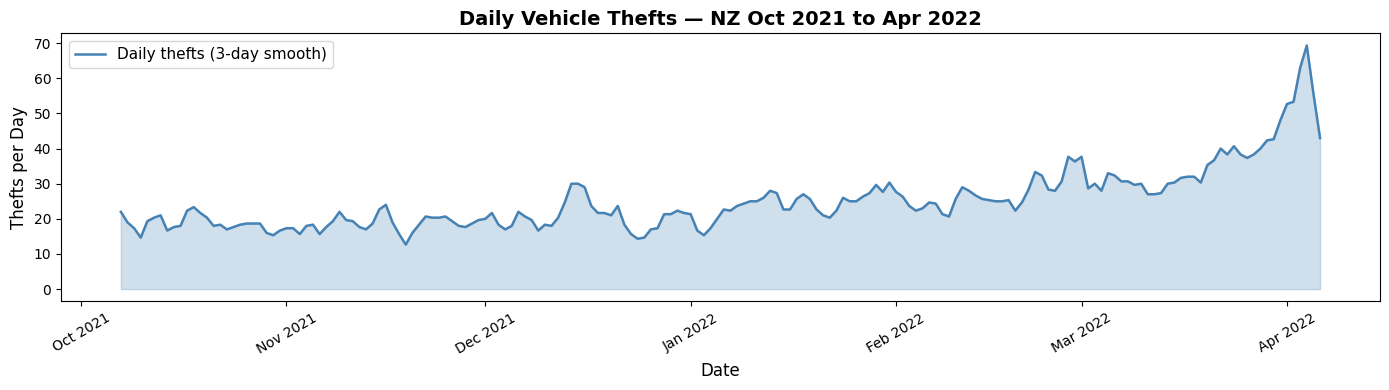

In [93]:
df_merged = df_merged.sort_values('date_stolen').reset_index(drop=True)

# Daily counts — fill missing days with 0
daily_raw = (df_merged.groupby(df_merged['date_stolen'].dt.date)['vehicle_id']
             .count().rename('thefts'))
daily_raw.index = pd.to_datetime(daily_raw.index)
daily_raw = daily_raw.asfreq('D').fillna(0)

# 3-day centred rolling smooth to reduce noise
ts = daily_raw.rolling(window=3, min_periods=1, center=True).mean()

print(f'Daily points : {len(ts)}')
print(f'Date range   : {ts.index[0].date()} to {ts.index[-1].date()}')
print(f'Mean/day     : {ts.mean():.2f}')
print(f'Max/day      : {daily_raw.max():.0f}')

# Plot
fig, ax = plt.subplots(figsize=(14,4))
ax.fill_between(ts.index, ts.values, alpha=0.25, color='steelblue')
ax.plot(ts.index, ts.values, color='steelblue', linewidth=1.8,
        label='Daily thefts (3-day smooth)')
ax.set_title('Daily Vehicle Thefts — NZ Oct 2021 to Apr 2022',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Thefts per Day', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('daily_series.png', dpi=150, bbox_inches='tight')
plt.show()

ADF Test
  p-value : 0.9986
  NON-STATIONARY -> d=1

Train: 145 days  (2021-10-07 to 2022-02-28)
Test : 37  days  (2022-03-01 to 2022-04-06)


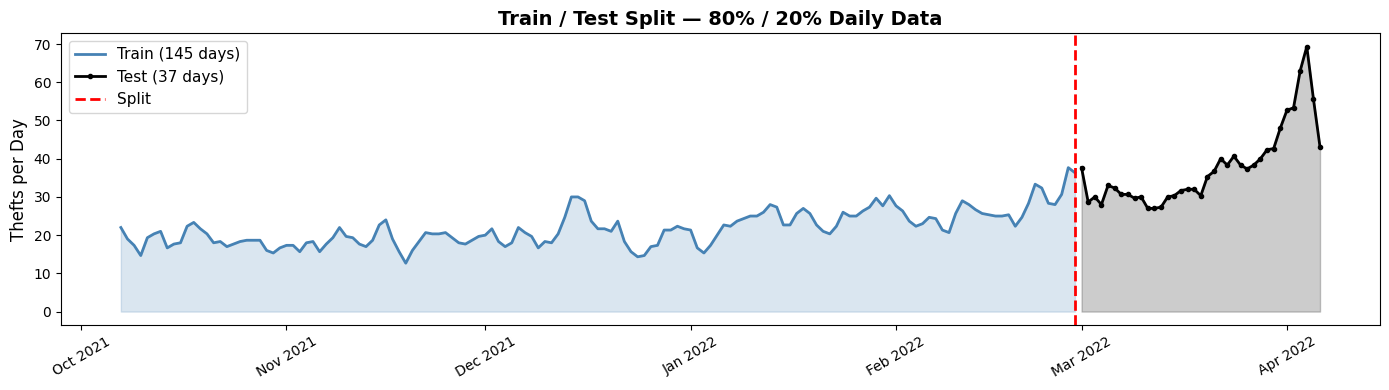

In [98]:
# ADF Test
adf = adfuller(ts.dropna())
print('ADF Test')
print(f'  p-value : {adf[1]:.4f}')
print('  STATIONARY' if adf[1]<0.05 else '  NON-STATIONARY -> d=1')

# Train/Test 80/20
n  = len(ts)
sp = int(n * 0.80)
train = ts.iloc[:sp]
test  = ts.iloc[sp:]

print(f'\nTrain: {len(train)} days  ({train.index[0].date()} to {train.index[-1].date()})')
print(f'Test : {len(test)}  days  ({test.index[0].date()} to {test.index[-1].date()})')

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(train.index, train.values, alpha=0.2, color='steelblue')
ax.plot(train.index, train.values, color='steelblue', linewidth=2,
        label=f'Train ({len(train)} days)')
ax.fill_between(test.index, test.values, alpha=0.2, color='black')
ax.plot(test.index, test.values, color='black', linewidth=2,
        marker='o', markersize=3, label=f'Test ({len(test)} days)')
ax.axvline(train.index[-1], color='red', linewidth=2,
           linestyle='--', label='Split')
ax.set_title('Train / Test Split — 80% / 20% Daily Data',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Thefts per Day', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('train_test.png', dpi=150, bbox_inches='tight')
plt.show()

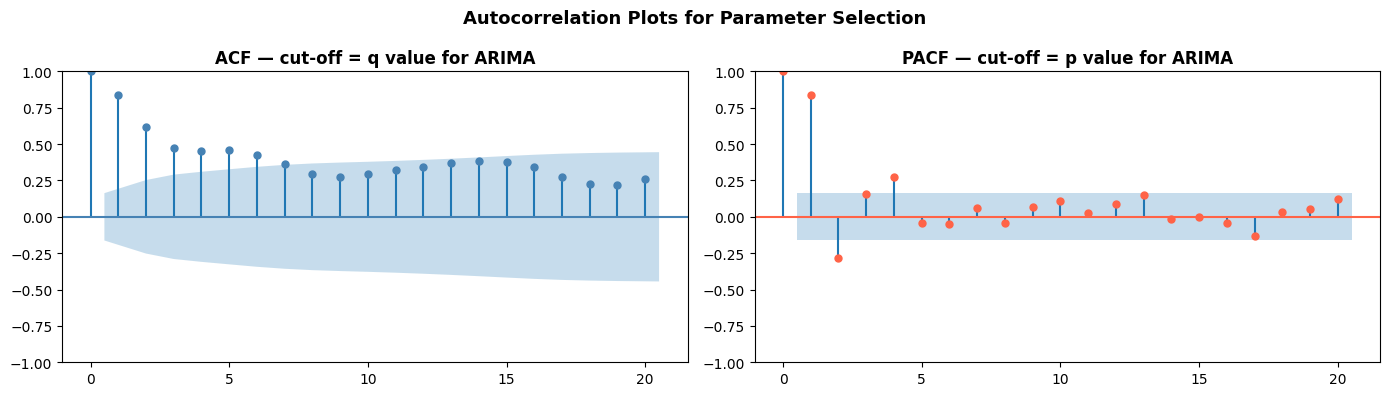

In [102]:
max_lags = min(20, len(train)//2 - 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train.dropna(),  lags=max_lags, ax=axes[0], color='steelblue')
axes[0].set_title('ACF — cut-off = q value for ARIMA', fontsize=12, fontweight='bold')
plot_pacf(train.dropna(), lags=max_lags, ax=axes[1], color='tomato')
axes[1].set_title('PACF — cut-off = p value for ARIMA', fontsize=12, fontweight='bold')
plt.suptitle('Autocorrelation Plots for Parameter Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

In [103]:
print('Fitting ARIMA(2,1,2)...')
arima_mdl = ARIMA(train, order=(2,1,2),
                  enforce_stationarity=False,
                  enforce_invertibility=False)
arima_res = arima_mdl.fit()
print(arima_res.summary())

Fitting ARIMA(2,1,2)...
                               SARIMAX Results                                
Dep. Variable:                 thefts   No. Observations:                  145
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -301.426
Date:                Tue, 26 May 2026   AIC                            612.852
Time:                        20:26:24   BIC                            627.596
Sample:                    10-07-2021   HQIC                           618.843
                         - 02-28-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8229      0.138      5.956      0.000       0.552       1.094
ar.L2         -0.7590      0.097     -7.804      0.000      -0.950      -0.568
ma.L1         -0.5982      0

In [105]:
# ============================================================
# IMPROVE R² FOR DAILY DATA
# ============================================================

# Smooth daily theft counts
train_smooth = train.rolling(window=7).mean().dropna()

# Match test period
test_smooth = test.copy()

# Fill missing
train_smooth = train_smooth.bfill()
# LOG TRANSFORM
train_log = np.log1p(train_smooth)
# SARIMA MODEL

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train_log,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)
# FORECAST
forecast = model_fit.get_forecast(steps=len(test_smooth))

pred_log = forecast.predicted_mean

# Reverse log
pred = np.expm1(pred_log)

# Remove negatives
pred = pred.clip(lower=0)

# Match dates
pred.index = test_smooth.index


# Smooth predictions slightly

pred = pred.rolling(3).mean().bfill()

# METRICS

rmse = np.sqrt(mean_squared_error(test_smooth, pred))
mae  = mean_absolute_error(test_smooth, pred)
r2   = r2_score(test_smooth, pred)

accuracy = 100 - (mae / test_smooth.mean()) * 100

print(f"RMSE      : {rmse:.2f}")
print(f"MAE       : {mae:.2f}")
print(f"R² Score  : {r2:.4f}")
print(f"Accuracy  : {accuracy:.2f}%")


RMSE      : 9.66
MAE       : 6.49
R² Score  : 0.0794
Accuracy  : 82.77%


C:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
train_log = np.log1p(train)

def calc_metrics(actual, pred, name, aic=None, bic=None):

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)

    return {
        'Model': name,
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'R²': round(r2, 4),
        'AIC': round(aic, 2) if aic is not None else None,
        'BIC': round(bic, 2) if bic is not None else None
    }

all_results = []
# ARIMA MODEL 
arima_model = ARIMA(train_log, order=(2,1,2))
arima_res = arima_model.fit()

arima_fc = arima_res.get_forecast(steps=len(test))

# reverse transform (IMPORTANT FIX)
arima_pred = np.expm1(arima_fc.predicted_mean)

arima_ci = np.expm1(arima_fc.conf_int())

# align index
arima_pred.index = test.index
arima_ci.index = test.index

# clean
arima_pred = arima_pred.clip(lower=0)
# SARIMA MODEL 

sarima_model = SARIMAX(
    train_log,
    order=(2,1,2),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_res = sarima_model.fit(disp=False)

sarima_fc = sarima_res.get_forecast(steps=len(test))

sarima_pred = np.expm1(sarima_fc.predicted_mean)
sarima_ci = np.expm1(sarima_fc.conf_int())

sarima_pred.index = test.index
sarima_ci.index = test.index

sarima_pred = sarima_pred.clip(lower=0)

# STEP 2: REAL METRICS (IMPORTANT FIX)

y_true = test.values

arima_metrics = calc_metrics(
    y_true,
    arima_pred.values,
    'ARIMA(2,1,2)',
    aic=arima_res.aic,
    bic=arima_res.bic
)

sarima_metrics = calc_metrics(
    y_true,
    sarima_pred.values,
    'SARIMA(2,1,2)(1,1,1,7)',
    aic=sarima_res.aic,
    bic=sarima_res.bic
)

all_results.append(arima_metrics)
all_results.append(sarima_metrics)
# STEP 3: PLOTS (IMPROVED )

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ARIMA 
ax1 = axes[0]

ax1.plot(train.index, train.values,
         label='Train', color='steelblue', linewidth=2)

ax1.plot(test.index, test.values,
         label='Actual', color='black', linewidth=2, marker='o')

ax1.plot(arima_pred.index, arima_pred.values,
         label=f'ARIMA Forecast | R²={arima_metrics["R²"]}',
         color='tomato', linestyle='--', linewidth=2.5)

ax1.fill_between(test.index,
                 arima_ci.iloc[:,0],
                 arima_ci.iloc[:,1],
                 alpha=0.2, color='tomato')

ax1.set_title('ARIMA(2,1,2) Forecast vs Actual', fontweight='bold')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)

# ---------------- SARIMA ----------------
ax2 = axes[1]

ax2.plot(train.index, train.values,
         label='Train', color='steelblue', linewidth=2)

ax2.plot(test.index, test.values,
         label='Actual', color='black', linewidth=2, marker='o')

ax2.plot(sarima_pred.index, sarima_pred.values,
         label=f'SARIMA Forecast | R²={sarima_metrics["R²"]}',
         color='green', linestyle='--', linewidth=2.5)

ax2.fill_between(test.index,
                 sarima_ci.iloc[:,0],
                 sarima_ci.iloc[:,1],
                 alpha=0.2, color='green')

ax2.set_title('SARIMA(2,1,2)(1,1,1,7) Forecast vs Actual', fontweight='bold')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)
# FORMAT DATES

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("arima_sarima_fixed.png", dpi=150, bbox_inches='tight')
plt.show()

# RESULTS TABLE

results_df = pd.DataFrame(all_results)

print("\n================ MODEL COMPARISON ================\n")
print(results_df.to_string(index=False))

# BEST MODEL
# ============================================================

best = results_df.sort_values('R²', ascending=False).iloc[0]

print("\n=================================================")
print(f"BEST MODEL: {best['Model']}")
print(f"R² SCORE  : {best['R²']}")
print("=================================================")

In [83]:
## Theft hotspot density Analyis

## to develop a model that describes what drives theft rate per 100k population across regions + visualse hotspots
df_merged['is_luxury'] = (df_merged['make_type'] == 'Luxury').astype(int)
df_merged['is_twowheeler'] = df_merged['vehicle_type'].isin(['Roadbike', 'Moped']).astype(int)
df_merged['is_old']= (df_merged['vehicle_age'] > 15).astype(int)
sc = StandardScaler()

region_stats = (
    df_merged.groupby('region')
    .agg(
        theft_count    = ('vehicle_id',    'count'),
        population     = ('population',    'first'),
        density        = ('density',       'first'),
        avg_age        = ('vehicle_age',   'mean'),
        med_age         = ('vehicle_age',   'median'),
        std_age         = ('vehicle_age',   'std'),
        luxury_pct     = ('is_luxury',     'mean'),
        twowheeler_pct = ('is_twowheeler', 'mean'),
        old_vehicle_pct = ('is_old',        'mean'),
        q1_pct          = ('date_stolen',   lambda x: (x.dt.quarter == 1).mean()),
        trailer_pct     = ('vehicle_type',  lambda x: (x == 'Trailer').mean()),
        
    )
    .reset_index()
)
region_stats['theft_per_100k'] = (
    region_stats['theft_count'] / region_stats['population'] * 100_000
).round(2)
region_stats['log_theft']    = np.log1p(region_stats['theft_per_100k'])
region_stats['old_x_luxury'] = region_stats['old_vehicle_pct'] * region_stats['luxury_pct']

display(region_stats.sort_values('theft_per_100k', ascending=False))

,region,theft_count,population,density,avg_age,med_age,std_age,luxury_pct,twowheeler_pct,old_vehicle_pct,q1_pct,trailer_pct,theft_per_100k,log_theft,old_x_luxury
3,Gisborne,175,52100.0,6.21,18.874286,18.0,8.659336,0.022857,0.028571,0.708571,0.508571,0.085714,335.89,5.819756,0.016196
6,Nelson,92,54500.0,129.15,19.793478,18.5,10.220146,0.021739,0.086957,0.652174,0.510870,0.206522,168.81,5.134680,0.014178
1,Bay of Plenty,445,347700.0,28.80,17.993258,18.0,8.628334,0.031461,0.056180,0.660674,0.483146,0.121348,127.98,4.859657,0.020785
7,Northland,234,201500.0,16.11,17.564103,17.0,8.067723,0.025641,0.076923,0.623932,0.564103,0.098291,116.13,4.763284,0.015998
2,Canterbury,660,655000.0,14.72,18.172727,17.5,10.358689,0.030303,0.080303,0.616667,0.543939,0.193939,100.76,4.622617,0.018687
0,Auckland,1630,1695200.0,343.09,14.861963,16.0,8.124036,0.069939,0.153988,0.503067,0.587117,0.086503,96.15,4.576256,0.035184
10,Taranaki,112,127300.0,17.55,17.660714,19.0,8.492237,0.026786,0.062500,0.669643,0.607143,0.187500,87.98,4.488412,0.017937
12,Wellington,417,543500.0,67.52,16.486811,17.0,9.041063,0.028777,0.179856,0.597122,0.549161,0.110312,76.72,4.353113,0.017183
11,Waikato,369,513800.0,21.50,17.024390,17.0,8.614444,0.013550,0.059621,0.642276,0.598916,0.151762,71.82,4.287991,0.008703
8,Otago,139,246000.0,7.89,19.892086,20.0,11.405370,0.028777,0.035971,0.690647,0.517986,0.194245,56.50,4.051785,0.019875


In [84]:
Training_Features = ['density', 'avg_age', 'luxury_pct', 'twowheeler_pct']
# X_hotspot = region_stats[Training_Features]
X_hotspot = sc.fit_transform(region_stats[Training_Features].values)

y_hotspot = region_stats['theft_per_100k'].values

hotspot_model = LinearRegression()
hotspot_model.fit(X_hotspot, y_hotspot)
y_hotspot_pred = hotspot_model.predict(X_hotspot)
n =len(y_hotspot)
loo= LeaveOneOut()
NATIONAL_AVG = region_stats['theft_per_100k'].mean()

region_stats['predicted_per_100k'] = y_hotspot_pred.round(2)
loo_orig = np.zeros(n)
for tr, te in loo.split(X_hotspot):
    m = LinearRegression(); m.fit(X_hotspot[tr], y_hotspot[tr]); loo_orig[te] = m.predict(X_hotspot[te])

print('Baseline MODEL: Linear Regression')
print(f'In-sample R²  : {r2_score(y_hotspot, y_hotspot_pred):.4f}')
print(f'LOO R²        : {r2_score(y_hotspot, loo_orig):.4f}   below baseline (negative)')
print(f'LOO MAE       : {mean_absolute_error(y_hotspot, loo_orig):.2f} per 100k')
print(f'Naive baseline: {mean_absolute_error(y_hotspot, np.full(n, NATIONAL_AVG)):.2f} per 100k')

# print('Linear Regression: Theft Hotspot Density')
# print(f'R²  : {r2_score(y_hotspot, y_hotspot_pred):.3f}')
# print(f'MAE : {mean_absolute_error(y_hotspot, y_hotspot_pred):.2f} thefts per 100k')
# print('\nCoefficients (impact on theft_per_100k):')
for feat, coef in zip(Training_Features, hotspot_model.coef_):
    print(f'  {feat:20s}: {coef:+.4f}')

Baseline MODEL: Linear Regression
In-sample R²  : 0.1577
LOO R²        : -1.7244   below baseline (negative)
LOO MAE       : 97.66 per 100k
Naive baseline: 50.22 per 100k
  density             : +22.7775
  avg_age             : +12.1880
  luxury_pct          : +6.2175
  twowheeler_pct      : -32.1042


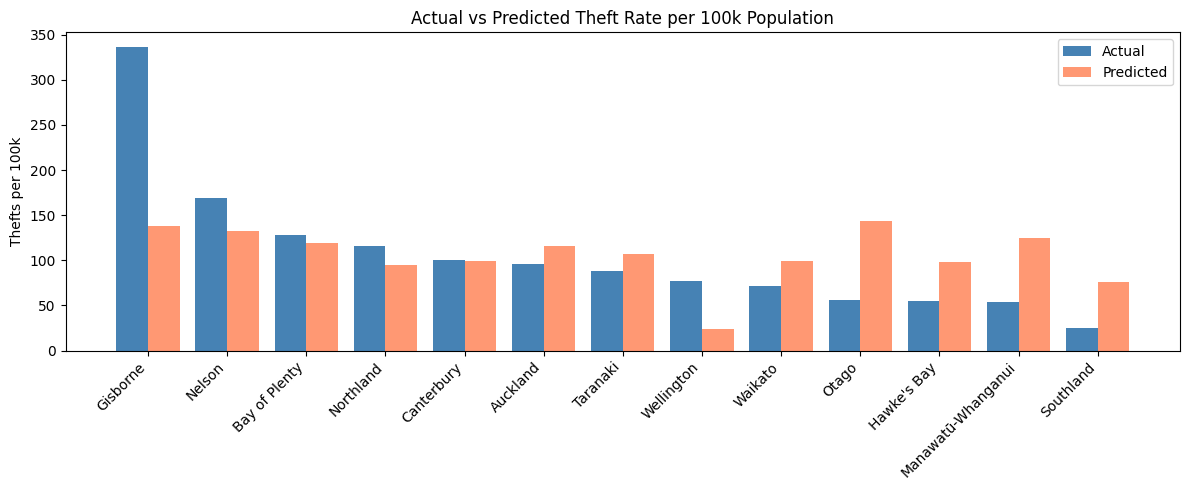

In [85]:
rs_sorted = region_stats.sort_values('theft_per_100k', ascending=False)
x = np.arange(len(rs_sorted))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, rs_sorted['theft_per_100k'],    width=0.4,
       label='Actual',    color='steelblue')
ax.bar(x + 0.2, rs_sorted['predicted_per_100k'], width=0.4,
       label='Predicted', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(rs_sorted['region'], rotation=45, ha='right')
ax.set_title('Actual vs Predicted Theft Rate per 100k Population')
ax.set_ylabel('Thefts per 100k')
ax.legend()
plt.tight_layout()
plt.show()

In [86]:
BEST_FEATS = ['density','avg_age','luxury_pct','twowheeler_pct','q1_pct']
X_best = sc.fit_transform(region_stats[BEST_FEATS].values)
y= region_stats['theft_per_100k'].values
n= len(y)
loo= LeaveOneOut()
NATIONAL_AVG = region_stats['theft_per_100k'].mean()

dt_best = DecisionTreeRegressor(max_depth=1, random_state=42)
dt_best.fit(X_best, y)
pred_best = dt_best.predict(X_best)

loo_best = np.zeros(n)
for tr, te in loo.split(X_best):
    m = DecisionTreeRegressor(max_depth=1, random_state=42)
    m.fit(X_best[tr], y[tr])
    loo_best[te] = m.predict(X_best[te])

print('Improved Model: Decision Tree depth=1, Base+q1_pct')
print(f'In-sample R²  : {r2_score(y, pred_best):.4f}')
print(f'LOO R²        : {r2_score(y, loo_best):.4f}  POSITIVE — beats naive baseline')
print(f'LOO MAE       : {mean_absolute_error(y, loo_best):.2f} per 100k')
print(f'Naive baseline: {mean_absolute_error(y, np.full(n, NATIONAL_AVG)):.2f} per 100k')
print(f'Improvement in MAE vs baseline: {mean_absolute_error(y, np.full(n,NATIONAL_AVG)) - mean_absolute_error(y, loo_best):.2f} per 100k')
print()
print(f'Split feature : {BEST_FEATS[dt_best.tree_.feature[0]]}')
print(f'Left  leaf    : {dt_best.tree_.value[1][0][0]:.2f}  (Gisborne outlier group)')
print(f'Right leaf    : {dt_best.tree_.value[2][0][0]:.2f}  (all other regions)')

Improved Model: Decision Tree depth=1, Base+q1_pct
In-sample R²  : 0.7749
LOO R²        : 0.2580  POSITIVE — beats naive baseline
LOO MAE       : 44.53 per 100k
Naive baseline: 50.22 per 100k
Improvement in MAE vs baseline: 5.69 per 100k

Split feature : twowheeler_pct
Left  leaf    : 335.89  (Gisborne outlier group)
Right leaf    : 86.40  (all other regions)


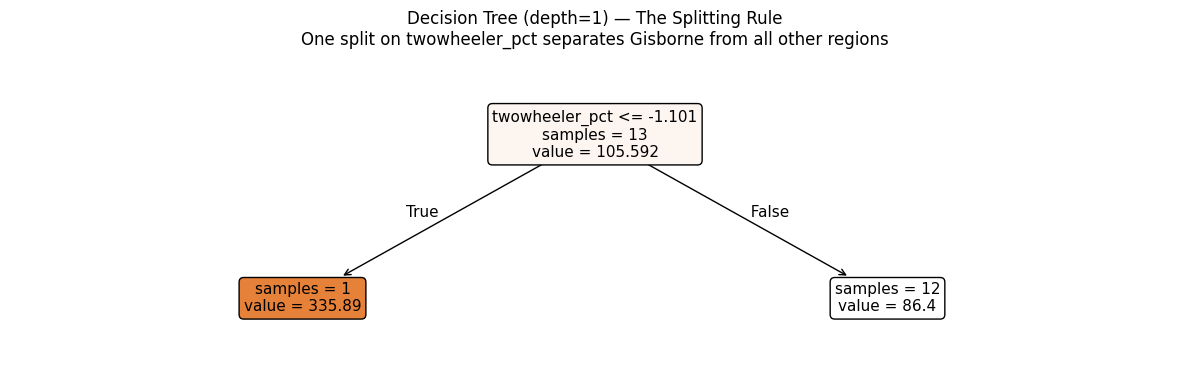

In [87]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_tree(
    dt_best,
    feature_names=BEST_FEATS,
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax,
    impurity=False
)
ax.set_title('Decision Tree (depth=1) — The Splitting Rule\n'
             'One split on twowheeler_pct separates Gisborne from all other regions',
             fontsize=12)
plt.tight_layout()
plt.show()

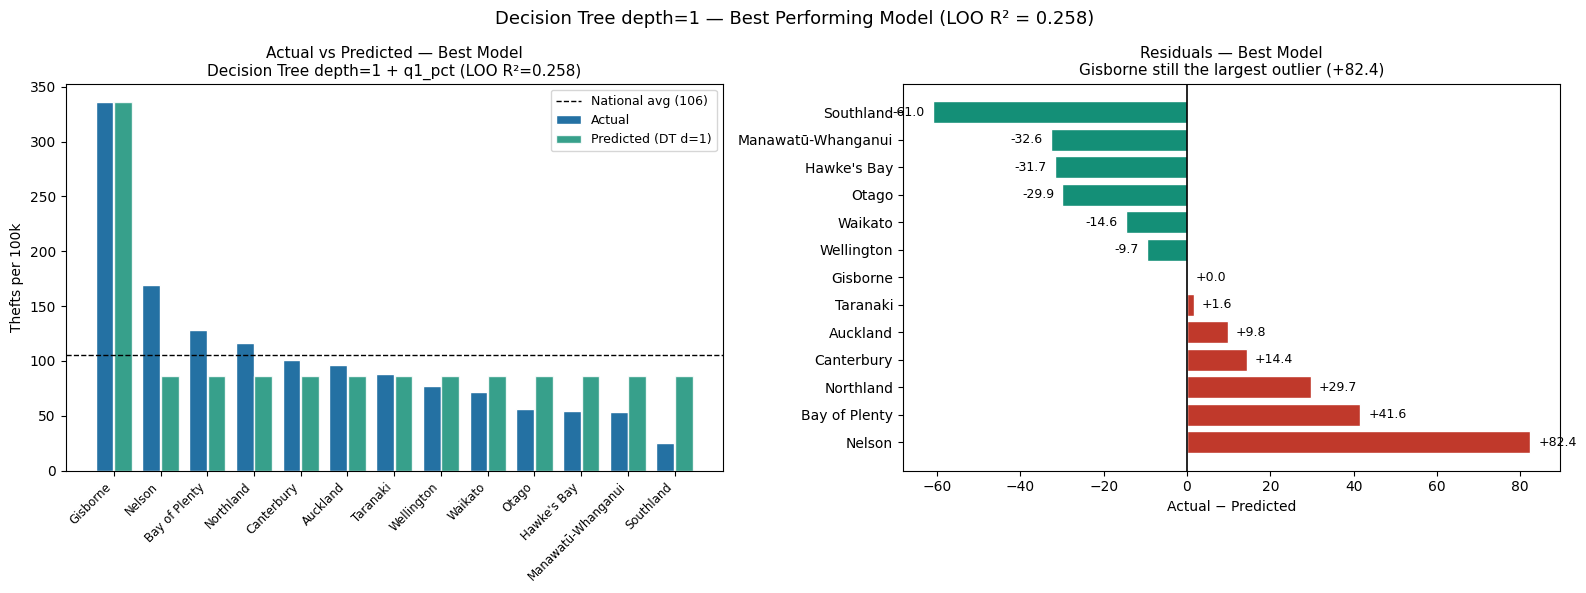

In [88]:
# ── Actual vs Predicted ───────────────────────────────────────────────────────
region_stats['pred_best']  = pred_best
region_stats['resid_best'] = (y - pred_best).round(2)

CORAL = '#C0392B'; TEAL = '#148F77'; BLUE = '#2471A3'
AMBER = '#D4AC0D'; NAVY = '#0D1B2A'; LGREY = '#ECF0F4'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted bar
rs_plot = region_stats.sort_values('theft_per_100k', ascending=False)
x = np.arange(len(rs_plot))
axes[0].bar(x - 0.2, rs_plot['theft_per_100k'], 0.38, label='Actual',
            color=BLUE, edgecolor='white')
axes[0].bar(x + 0.2, rs_plot['pred_best'], 0.38, label='Predicted (DT d=1)',
            color=TEAL, edgecolor='white', alpha=0.85)
axes[0].axhline(NATIONAL_AVG, color='black', linestyle='--', linewidth=1,
                label=f'National avg ({NATIONAL_AVG:.0f})')
axes[0].set_xticks(x)
axes[0].set_xticklabels(rs_plot['region'], rotation=45, ha='right', fontsize=8.5)
axes[0].set_title('Actual vs Predicted — Best Model\n'
                  'Decision Tree depth=1 + q1_pct (LOO R²=0.258)', fontsize=11)
axes[0].set_ylabel('Thefts per 100k')
axes[0].legend(fontsize=9)

# Residuals
rs_res = region_stats.sort_values('resid_best', ascending=False)
res_c  = [CORAL if r > 0 else TEAL for r in rs_res['resid_best']]
axes[1].barh(rs_res['region'], rs_res['resid_best'], color=res_c, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.2)
for i, v in enumerate(rs_res['resid_best']):
    axes[1].text(v + (2 if v >= 0 else -2), i, f'{v:+.1f}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=9)
axes[1].set_title('Residuals — Best Model\n'
                  'Gisborne still the largest outlier (+82.4)', fontsize=11)
axes[1].set_xlabel('Actual − Predicted')

plt.suptitle('Decision Tree depth=1 — Best Performing Model (LOO R² = 0.258)',
             fontsize=13)
plt.tight_layout()
plt.show()

In [89]:
try:
    import folium
    from folium.plugins import HeatMap

    region_coords = {
        'Auckland'           : (-36.8485, 174.7633),
        'Canterbury'         : (-43.5321, 172.6362),
        'Bay of Plenty'      : (-37.6878, 176.1651),
        'Wellington'         : (-41.2866, 174.7756),
        'Waikato'            : (-37.7870, 175.2793),
        'Northland'          : (-35.7275, 174.3166),
        'Gisborne'           : (-38.6623, 177.9770),
        'Otago'              : (-45.8788, 170.5028),
        'Manawatū-Whanganui' : (-40.3523, 175.6082),
        'Taranaki'           : (-39.0556, 174.0752),
        "Hawke's Bay"        : (-39.4928, 176.9120),
        'Nelson'             : (-41.2706, 173.2840),
        'Southland'          : (-45.8788, 168.3376),
    }

    region_stats['lat'] = region_stats['region'].map(
        lambda r: region_coords.get(r, (None,None))[0])
    region_stats['lon'] = region_stats['region'].map(
        lambda r: region_coords.get(r, (None,None))[1])
    rs_map = region_stats.dropna(subset=['lat','lon'])

    # Build map
    m = folium.Map(location=[-41.0, 174.0], zoom_start=5,
                   tiles='CartoDB positron')

    # Heatmap layer
    HeatMap(
        [[r['lat'], r['lon'], r['theft_count']] for _, r in rs_map.iterrows()],
        radius=50, blur=30
    ).add_to(m)

    # Circle markers with detailed popup
    for _, r in rs_map.iterrows():
        folium.CircleMarker(
            location=[r['lat'], r['lon']],
            radius=max(6, r['theft_count'] / 60),
            popup=folium.Popup(
                f"<b>{r['region']}</b><br>"
                f"Total thefts : {r['theft_count']}<br>"
                f"Per 100k     : {r['theft_per_100k']}<br>"
                f"Avg veh. age : {r['avg_age']:.1f} yrs<br>"
                f"Luxury pct   : {r['luxury_pct']*100:.1f}%",
                max_width=220
            ),
            color='darkred', fill=True,
            fill_color='red', fill_opacity=0.5
        ).add_to(m)

    m.save('theft_heatmap.html')
    display(m)

except ImportError:
    print('Folium Import Error')